# Purpose

- Test how different transformations of the variables can lead to different outcomes
- Notes:
  - Use OLS whenever possible


# Import packages


In [1]:
library(stats)
library(ggplot2)
library(patchwork)
library(tidyr)
library(dplyr)
library(reshape2)
library(ggnewscale)
library(splines)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths




# Generate transformed data


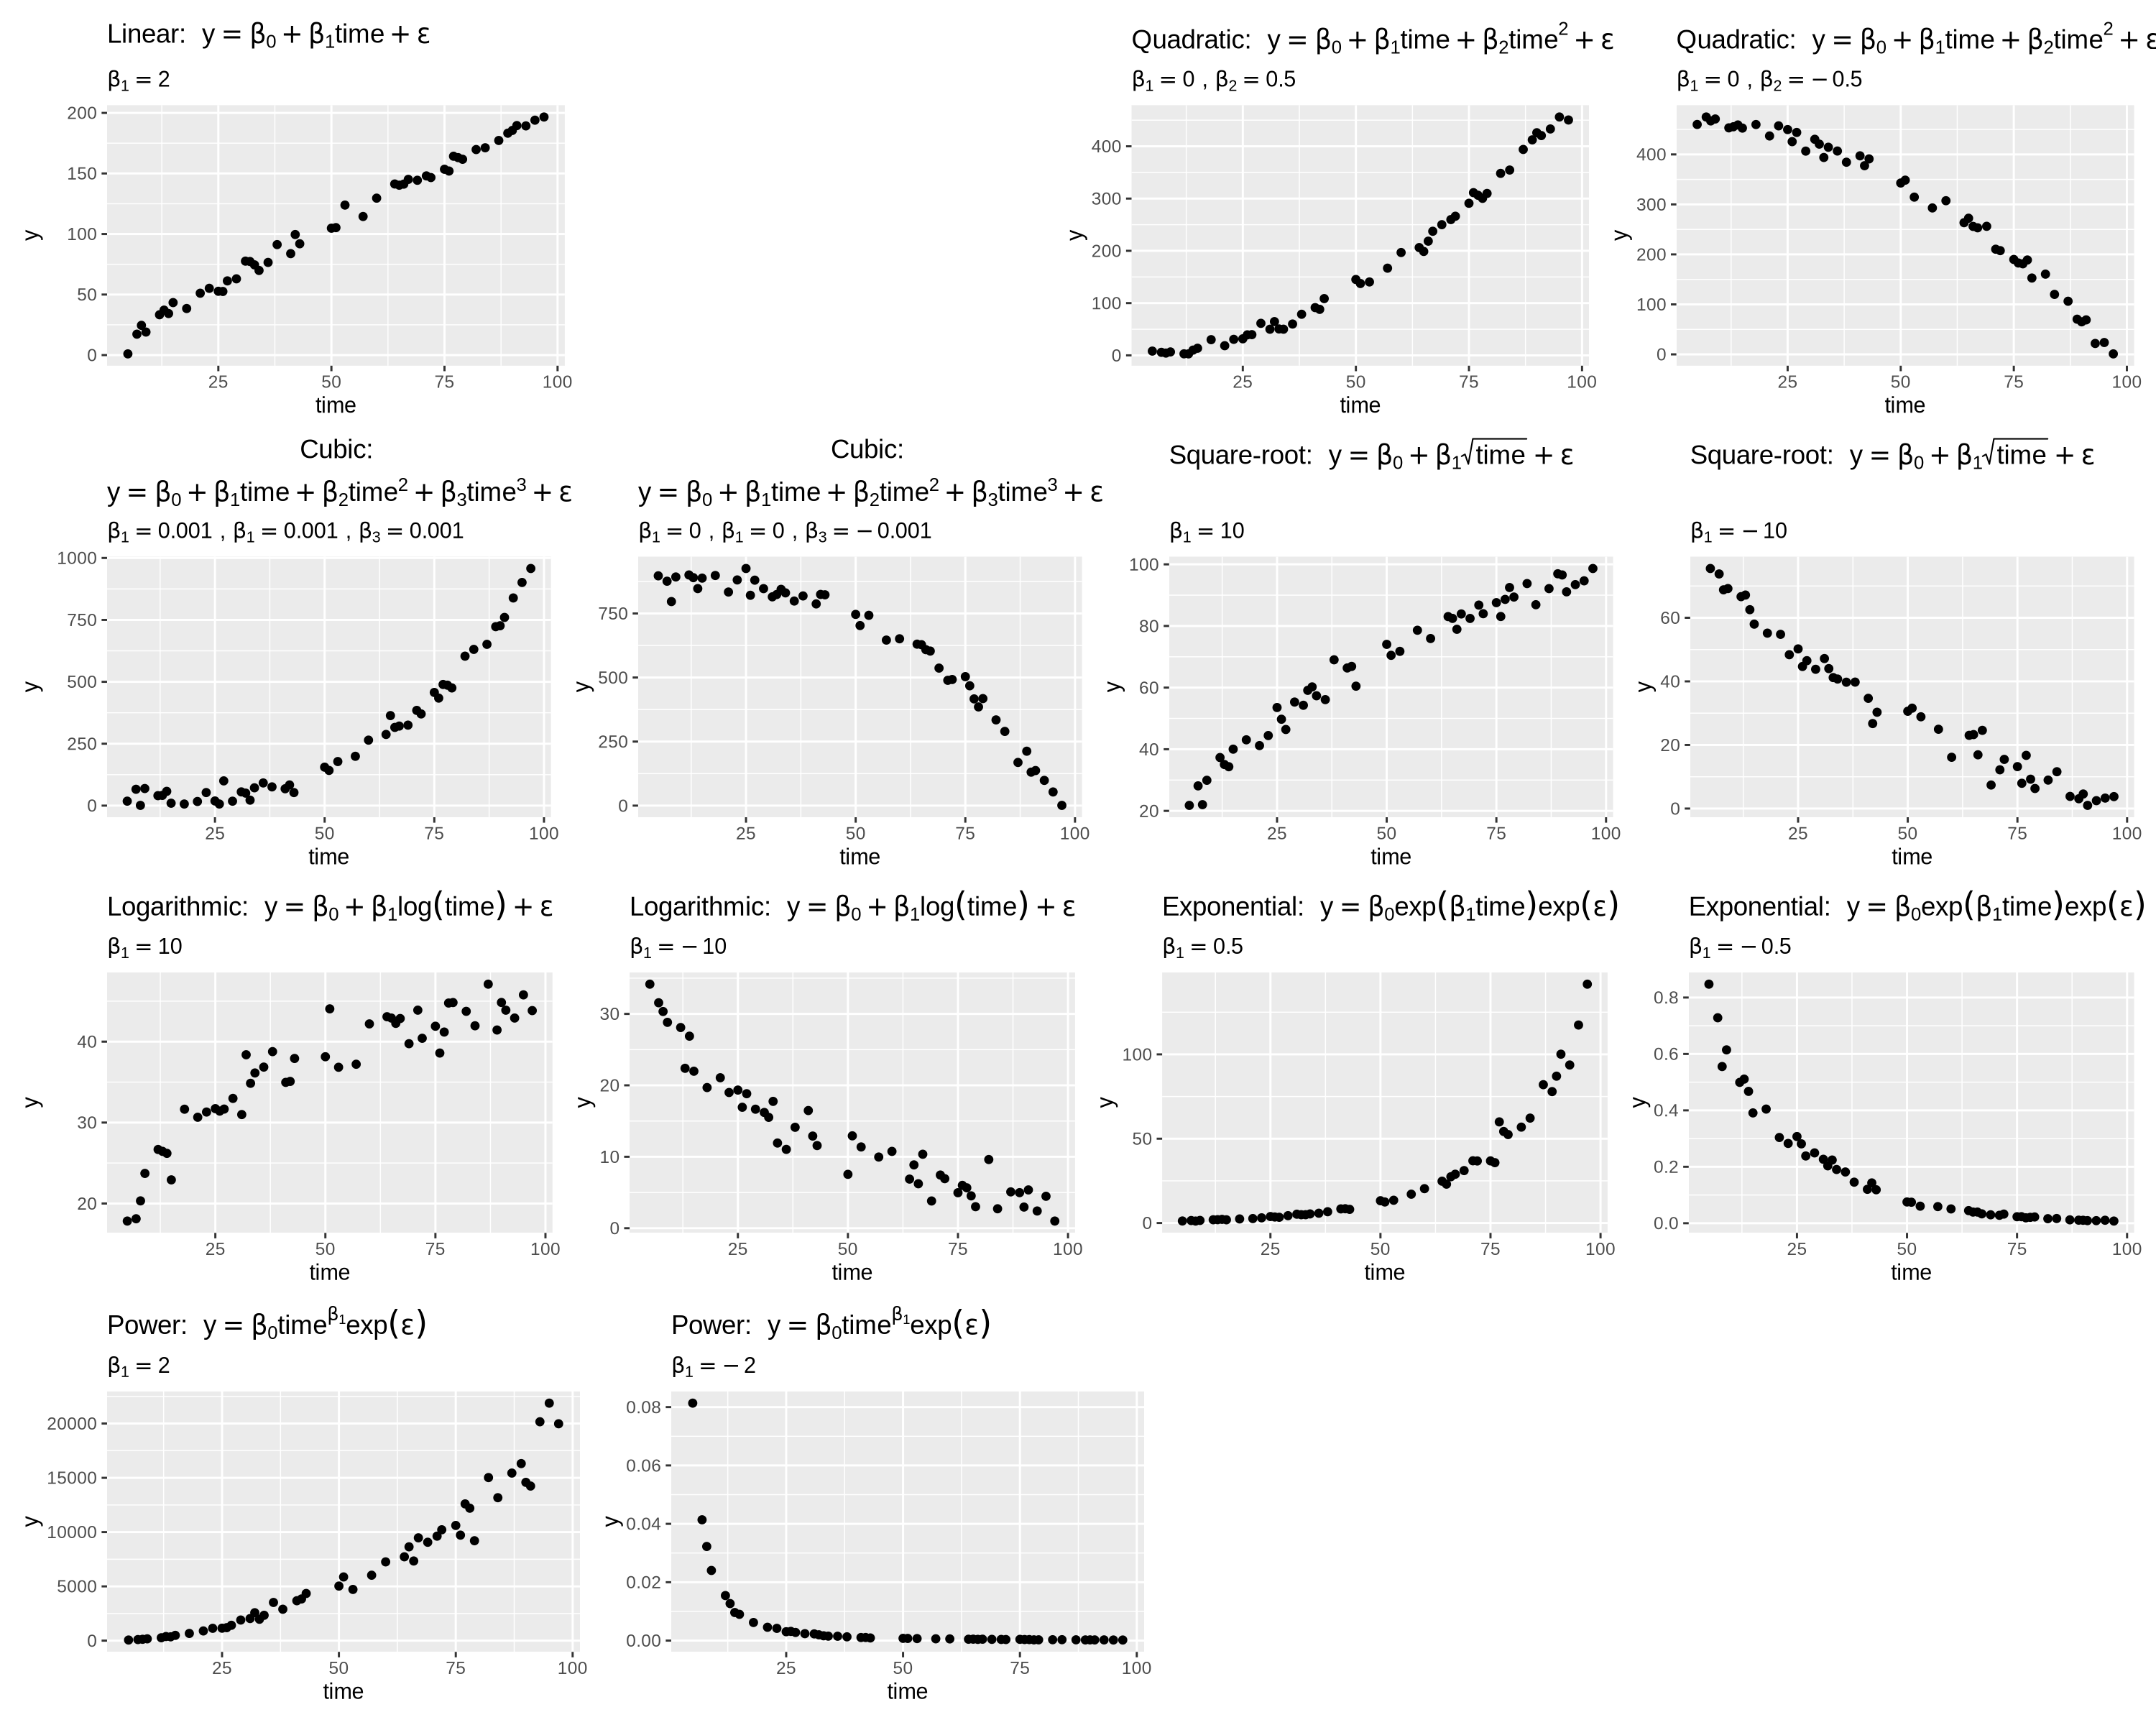

In [ ]:
set.seed(123) # For reproducibility

# Generate a random progression of time values from 1 to 100
time <- sort(sample(1:100, 50, replace = FALSE))

# Generate y values with a linear relationship to time and some normal noise
y <- 2 * time + rnorm(50, mean = 0, sd = 5)
data_linear <- data.frame(time = time, y = y)

# Generate y values with a quadratic relationship to time and some normal noise
## increasing
y_quadratic <- 0.05 * time + 0.05 * time^2 + rnorm(50, mean = 0, sd = 10)
data_quadratic <- data.frame(time = time, y = y_quadratic)
## decreasing
y_quadratic_dec <- 0.05 * time + -0.05 * time^2 + rnorm(50, mean = 0, sd = 10)
data_quadratic_dec <- data.frame(time = time, y = y_quadratic_dec)

# Generate y values with a cubic relationship to time and some normal noise
## increasing
y_cubic <- 0.001 * time + 0.0001 * time^2 + 0.001 * time^3 + rnorm(50, mean = 0, sd = 25)
data_cubic <- data.frame(time = time, y = y_cubic)
## decreasing
y_cubic_dec <- 0.001 * time + 0.0001 * time^2 + -0.001 * time^3 + rnorm(50, mean = 0, sd = 25)
data_cubic_dec <- data.frame(time = time, y = y_cubic_dec)

# Generate y values with a square-root relationship to time and some normal noise
## increasing
y_sqrt <- 10 * sqrt(time) + rnorm(50, mean = 0, sd = 3)
data_sqrt <- data.frame(time = time, y = y_sqrt)
## decreasing
y_sqrt_dec <- -10 * sqrt(time) + rnorm(50, mean = 0, sd = 3)
data_sqrt_dec <- data.frame(time = time, y = y_sqrt_dec)

# Generate y values with a logarithmic relationship to time and some normal noise
## increasing
y_log <- 10 * log(time) + rnorm(50, mean = 0, sd = 2)
data_log <- data.frame(time = time, y = y_log)
## decreasing
y_log_dec <- -10 * log(time) + rnorm(50, mean = 0, sd = 2)
data_log_dec <- data.frame(time = time, y = y_log_dec)

# Generate y values with an exponential relationship to time and some normal noise
## increasing
y_exp <- exp(0.05 * time + rnorm(50, mean = 0, sd = 0.1))
data_exp <- data.frame(time = time, y = y_exp)
## decreasing
y_exp_dec <- exp(-0.05 * time + rnorm(50, mean = 0, sd = 0.1))
data_exp_dec <- data.frame(time = time, y = y_exp_dec)

# Generate y values with a multiplicative relationship to time and some normal noise
## increasing
y_mult <- 2 * (time^2) * exp(rnorm(50, mean = 0, sd = 0.1))
data_mult <- data.frame(time = time, y = y_mult)

## decreasing
y_mult_dec <- 2 * (time^-2) * exp(rnorm(50, mean = 0, sd = 0.1))
data_mult_dec <- data.frame(time = time, y = y_mult_dec)


data_list <- list(
    data_linear, data_quadratic, data_quadratic_dec, data_cubic, data_cubic_dec,
    data_sqrt, data_sqrt_dec, data_log, data_log_dec, data_exp, data_exp_dec,
    data_mult, data_mult_dec
)

# Function to adjust data to make all values positive
adjust_data <- function(data) {
    min_value <- min(data$y)
    if (min_value <= 0) {
        data$y <- data$y + abs(min_value) + 1
    }
    return(data)
}

# Apply the adjustment to all data_ variables
data_list <- lapply(data_list, adjust_data)

# Reassign the adjusted data back to the original variables
data_linear <- data_list[[1]]
data_quadratic <- data_list[[2]]
data_quadratic_dec <- data_list[[3]]
data_cubic <- data_list[[4]]
data_cubic_dec <- data_list[[5]]
data_sqrt <- data_list[[6]]
data_sqrt_dec <- data_list[[7]]
data_log <- data_list[[8]]
data_log_dec <- data_list[[9]]
data_exp <- data_list[[10]]
data_exp_dec <- data_list[[11]]
data_mult <- data_list[[12]]
data_mult_dec <- data_list[[13]]


options(repr.plot.width = 15, repr.plot.height = 12, repr.plot.res = 200)

# Create scatterplots for each dataset
plot_linear <- ggplot(data_linear, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Linear: " ~ y == beta[0] + beta[1] * time + epsilon)) +
    labs(subtitle = bquote(beta[1] == 2))

plot_quadratic <- ggplot(data_quadratic, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Quadratic: " ~ y == beta[0] + beta[1] * time + beta[2] * time^2 + epsilon)) +
    labs(subtitle = bquote(beta[1] == 0 ~ "," ~ beta[2] == 0.5))
plot_quadratic_dec <- ggplot(data_quadratic_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Quadratic: " ~ y == beta[0] + beta[1] * time + beta[2] * time^2 + epsilon)) +
    labs(subtitle = bquote(beta[1] == 0 ~ "," ~ beta[2] == -0.5))

plot_cubic <- ggplot(data_cubic, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote(atop("Cubic: ", y == beta[0] + beta[1] * time + beta[2] * time^2 + beta[3] * time^3 + epsilon))) +
    labs(subtitle = bquote(beta[1] == 0.001 ~ "," ~ beta[1] == 0.001 ~ "," ~ beta[3] == 0.001))
plot_cubic_dec <- ggplot(data_cubic_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote(atop("Cubic: ", y == beta[0] + beta[1] * time + beta[2] * time^2 + beta[3] * time^3 + epsilon))) +
    labs(subtitle = bquote(beta[1] == 0 ~ "," ~ beta[1] == 0 ~ "," ~ beta[3] == -0.001))

plot_sqrt <- ggplot(data_sqrt, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Square-root: " ~ y == beta[0] + beta[1] * sqrt(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == 10))
plot_sqrt_dec <- ggplot(data_sqrt_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Square-root: " ~ y == beta[0] + beta[1] * sqrt(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == -10))

plot_log <- ggplot(data_log, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Logarithmic: " ~ y == beta[0] + beta[1] * log(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == 10))
plot_log_dec <- ggplot(data_log_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Logarithmic: " ~ y == beta[0] + beta[1] * log(time) + epsilon)) +
    labs(subtitle = bquote(beta[1] == -10))

plot_exp <- ggplot(data_exp, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Exponential: " ~ y == beta[0] * exp(beta[1] * time) * exp(epsilon))) +
    labs(subtitle = bquote(beta[1] == 0.5))
plot_exp_dec <- ggplot(data_exp_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Exponential: " ~ y == beta[0] * exp(beta[1] * time) * exp(epsilon))) +
    labs(subtitle = bquote(beta[1] == -0.5))

plot_mult <- ggplot(data_mult, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Power: " ~ y == beta[0] * time^beta[1] * exp(epsilon))) +
    labs(subtitle = bquote(beta[1] == 2))
plot_mult_dec <- ggplot(data_mult_dec, aes(x = time, y = y)) +
    geom_point() +
    ggtitle(bquote("Power: " ~ y == beta[0] * time^beta[1] * exp(epsilon))) +
    labs(subtitle = bquote(beta[1] == -2))

# Combine all plots using patchwork
(plot_linear | plot_spacer() | plot_quadratic | plot_quadratic_dec) /
    (plot_cubic | plot_cubic_dec | plot_sqrt | plot_sqrt_dec) /
    (plot_log | plot_log_dec | plot_exp | plot_exp_dec) /
    (plot_mult | plot_mult_dec | plot_spacer() | plot_spacer())


In [3]:
# Create a dataframe with a column "experiment" describing each experiment
experiment_df <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    )
)

print(experiment_df)


                Model
1              Linear
2           Quadratic
3       Quadratic Dec
4               Cubic
5           Cubic Dec
6         Square-root
7     Square-root Dec
8         Logarithmic
9     Logarithmic Dec
10        Exponential
11    Exponential Dec
12     Multiplicative
13 Multiplicative Dec


# Linear model

- The $\beta_1$ parameter can be interpreted as the marginal effect of $x$ on $y$:
  - if $x$ increases by 1 unit, the response variable $y$ changes on average by $\beta_1$ units
- This model can capture only linear relations
- The error is additive and normally distributed


In [4]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ time, data = data_linear)
model_quadratic <- lm(y ~ time, data = data_quadratic)
model_quadratic_dec <- lm(y ~ time, data = data_quadratic_dec)
model_cubic <- lm(y ~ time, data = data_cubic)
model_cubic_dec <- lm(y ~ time, data = data_cubic_dec)
model_sqrt <- lm(y ~ time, data = data_sqrt)
model_sqrt_dec <- lm(y ~ time, data = data_sqrt_dec)
model_log <- lm(y ~ time, data = data_log)
model_log_dec <- lm(y ~ time, data = data_log_dec)
model_exp <- lm(y ~ time, data = data_exp)
model_exp_dec <- lm(y ~ time, data = data_exp_dec)
model_mult <- lm(y ~ time, data = data_mult)
model_mult_dec <- lm(y ~ time, data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [5]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_linear <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_linear)

experiment_df <- cbind(experiment_df, Linear_Adj_R_Squared = adj_r_squared_df_linear$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9922407
2,Quadratic,0.9519875
3,Quadratic Dec,0.9419899
4,Cubic,0.8456979
5,Cubic Dec,0.8611056
6,Square-root,0.9519183


,Model,Linear_Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9922407
2,Quadratic,0.9519875
3,Quadratic Dec,0.9419899
4,Cubic,0.8456979
5,Cubic Dec,0.8611056
6,Square-root,0.9519183


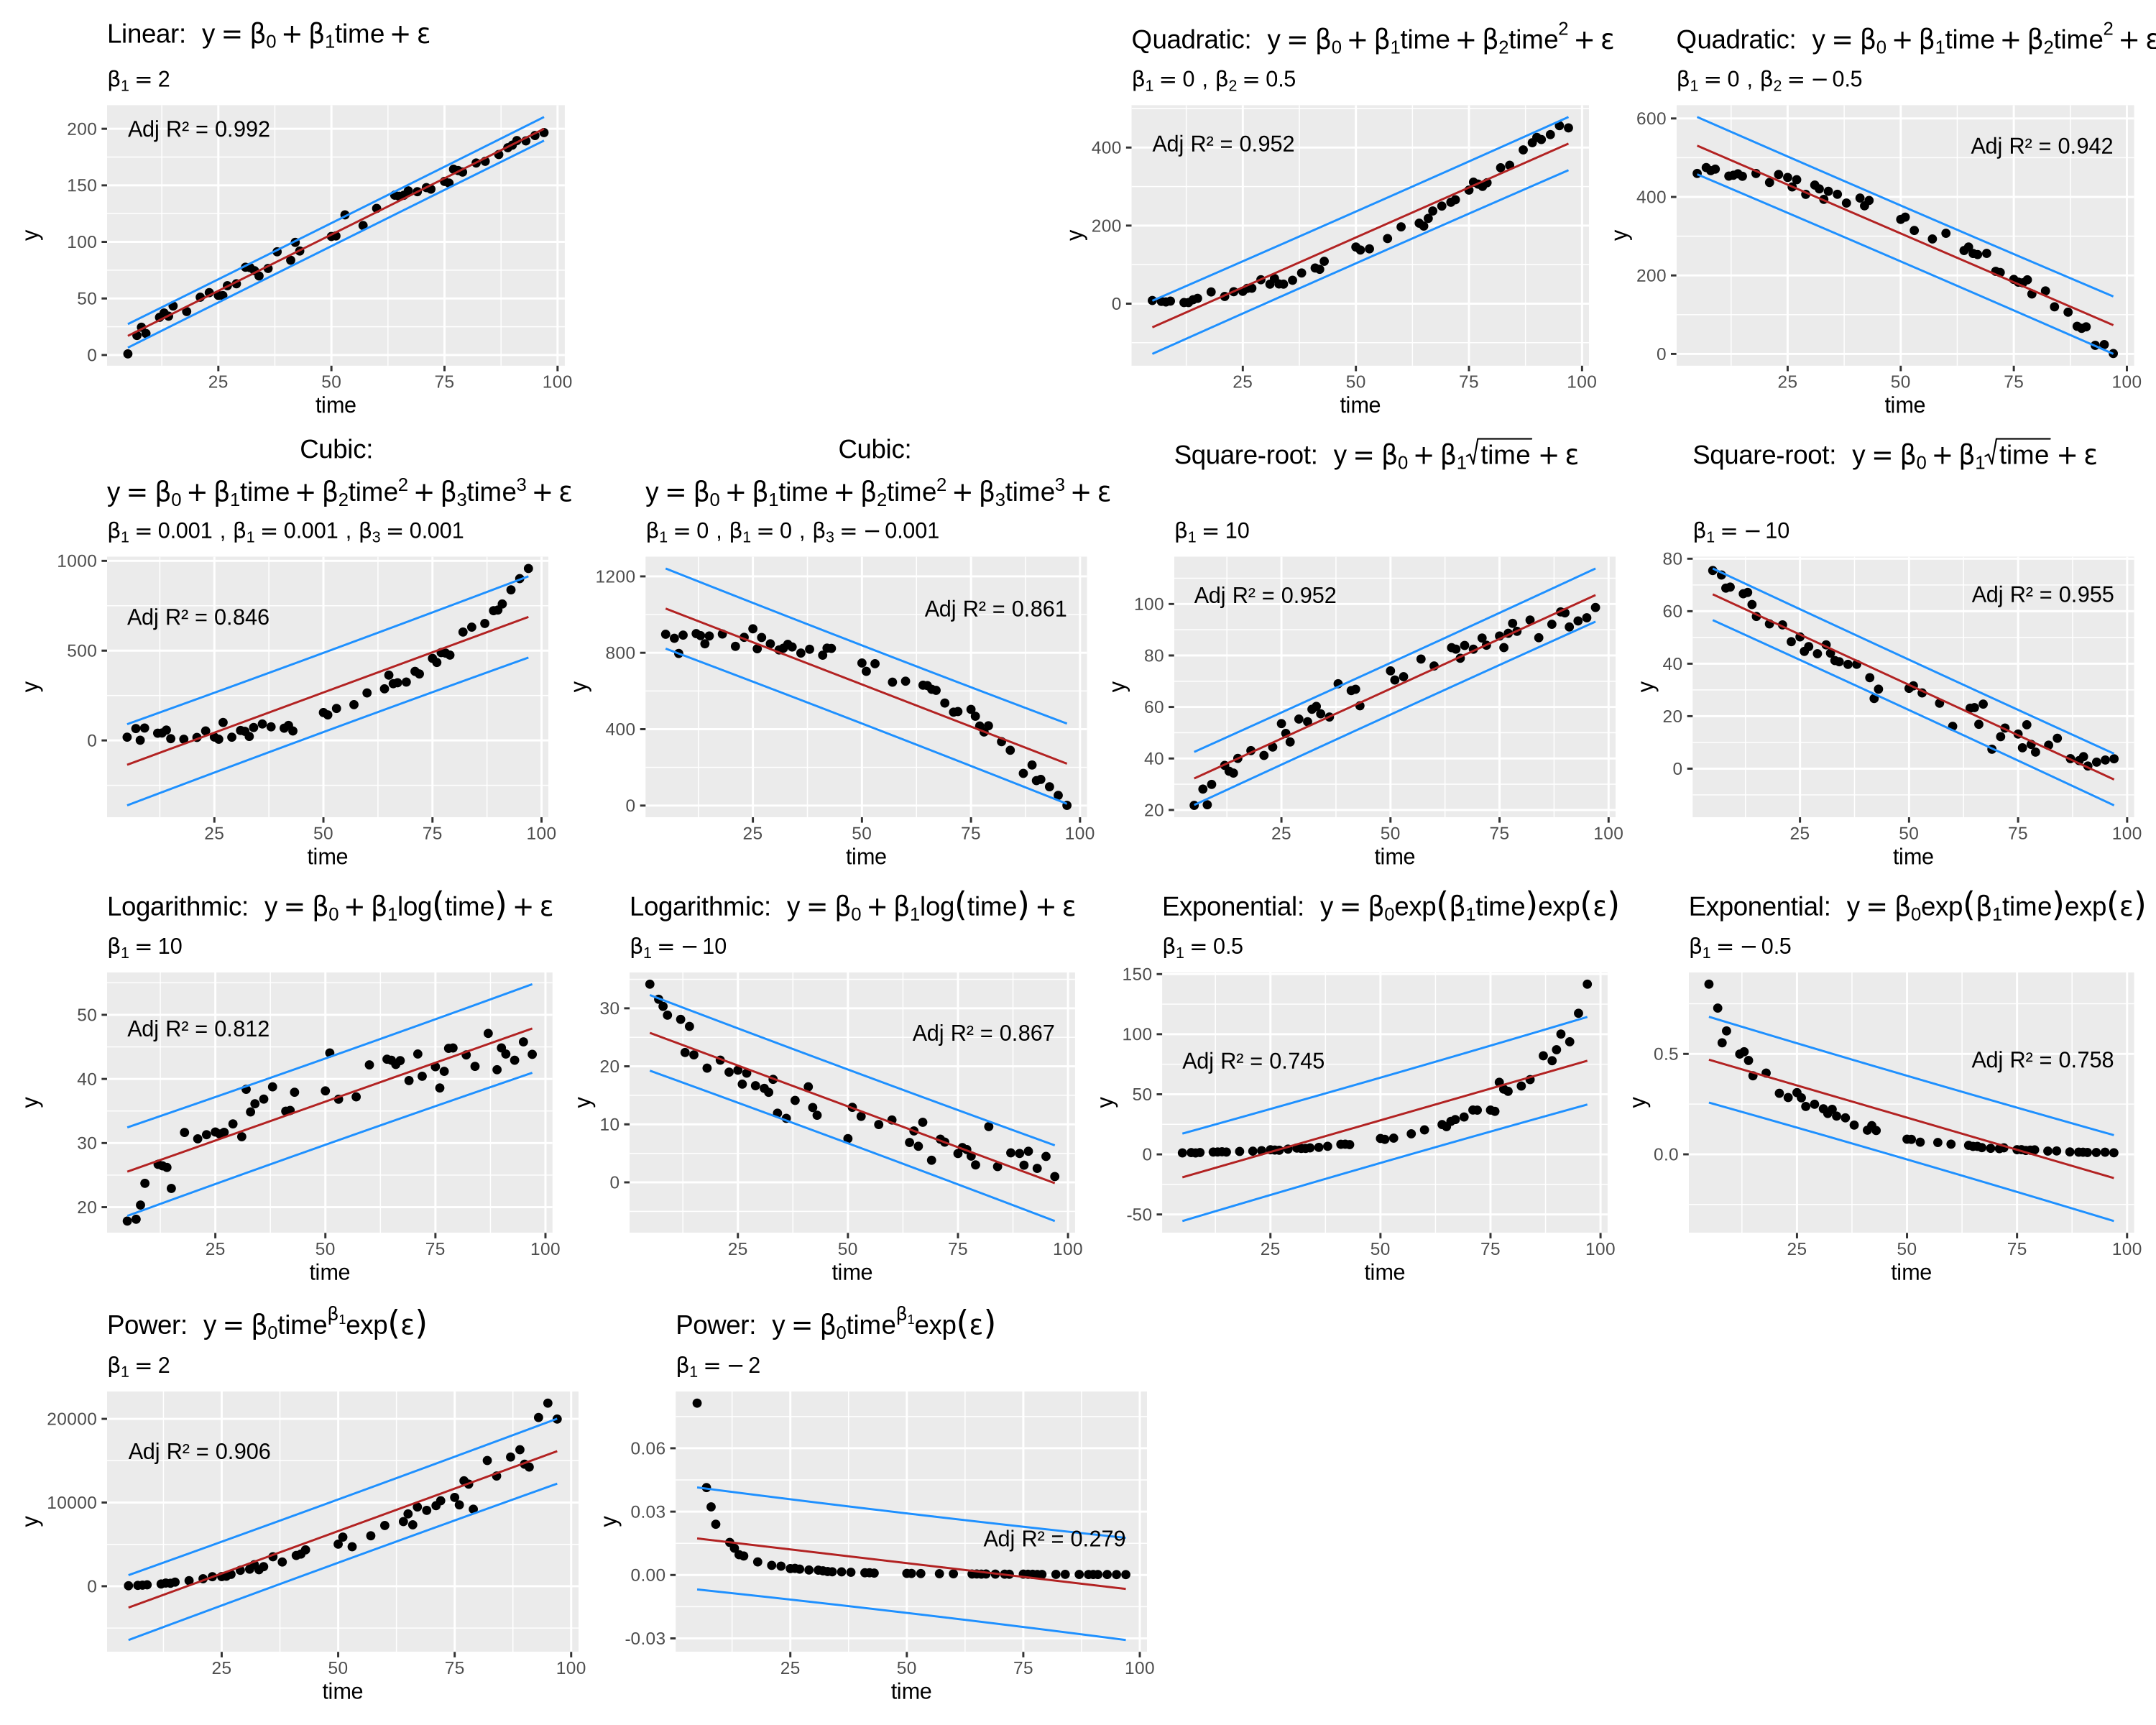

In [6]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Quadratic model

- This relation demonstrates increase or decrease with an acceleration due to the present of squared $x$.
- This model has an extremum (either a minimum or a maximum), when $x=−\beta_1/2\beta_2$. This means that the growth in the data will be changed by decline or vice versa with the increase of x. This makes the model potentially prone to overfitting, so it needs to be used with care
- The error is additive and normally distributed


In [7]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ time + I(time^2), data = data_linear)
model_quadratic <- lm(y ~ time + I(time^2), data = data_quadratic)
model_quadratic_dec <- lm(y ~ time + I(time^2), data = data_quadratic_dec)
model_cubic <- lm(y ~ time + I(time^2), data = data_cubic)
model_cubic_dec <- lm(y ~ time + I(time^2), data = data_cubic_dec)
model_sqrt <- lm(y ~ time + I(time^2), data = data_sqrt)
model_sqrt_dec <- lm(y ~ time + I(time^2), data = data_sqrt_dec)
model_log <- lm(y ~ time + I(time^2), data = data_log)
model_log_dec <- lm(y ~ time + I(time^2), data = data_log_dec)
model_exp <- lm(y ~ time + I(time^2), data = data_exp)
model_exp_dec <- lm(y ~ time + I(time^2), data = data_exp_dec)
model_mult <- lm(y ~ time + I(time^2), data = data_mult)
model_mult_dec <- lm(y ~ time + I(time^2), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [8]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_quad <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_quad)

experiment_df <- cbind(experiment_df, Quadratic_Adj_R_Squared = adj_r_squared_df_quad$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9930458
2,Quadratic,0.9965999
3,Quadratic Dec,0.9941927
4,Cubic,0.9888866
5,Cubic Dec,0.9857433
6,Square-root,0.9816979


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared
,<chr>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458
2,Quadratic,0.9519875,0.9965999
3,Quadratic Dec,0.9419899,0.9941927
4,Cubic,0.8456979,0.9888866
5,Cubic Dec,0.8611056,0.9857433
6,Square-root,0.9519183,0.9816979


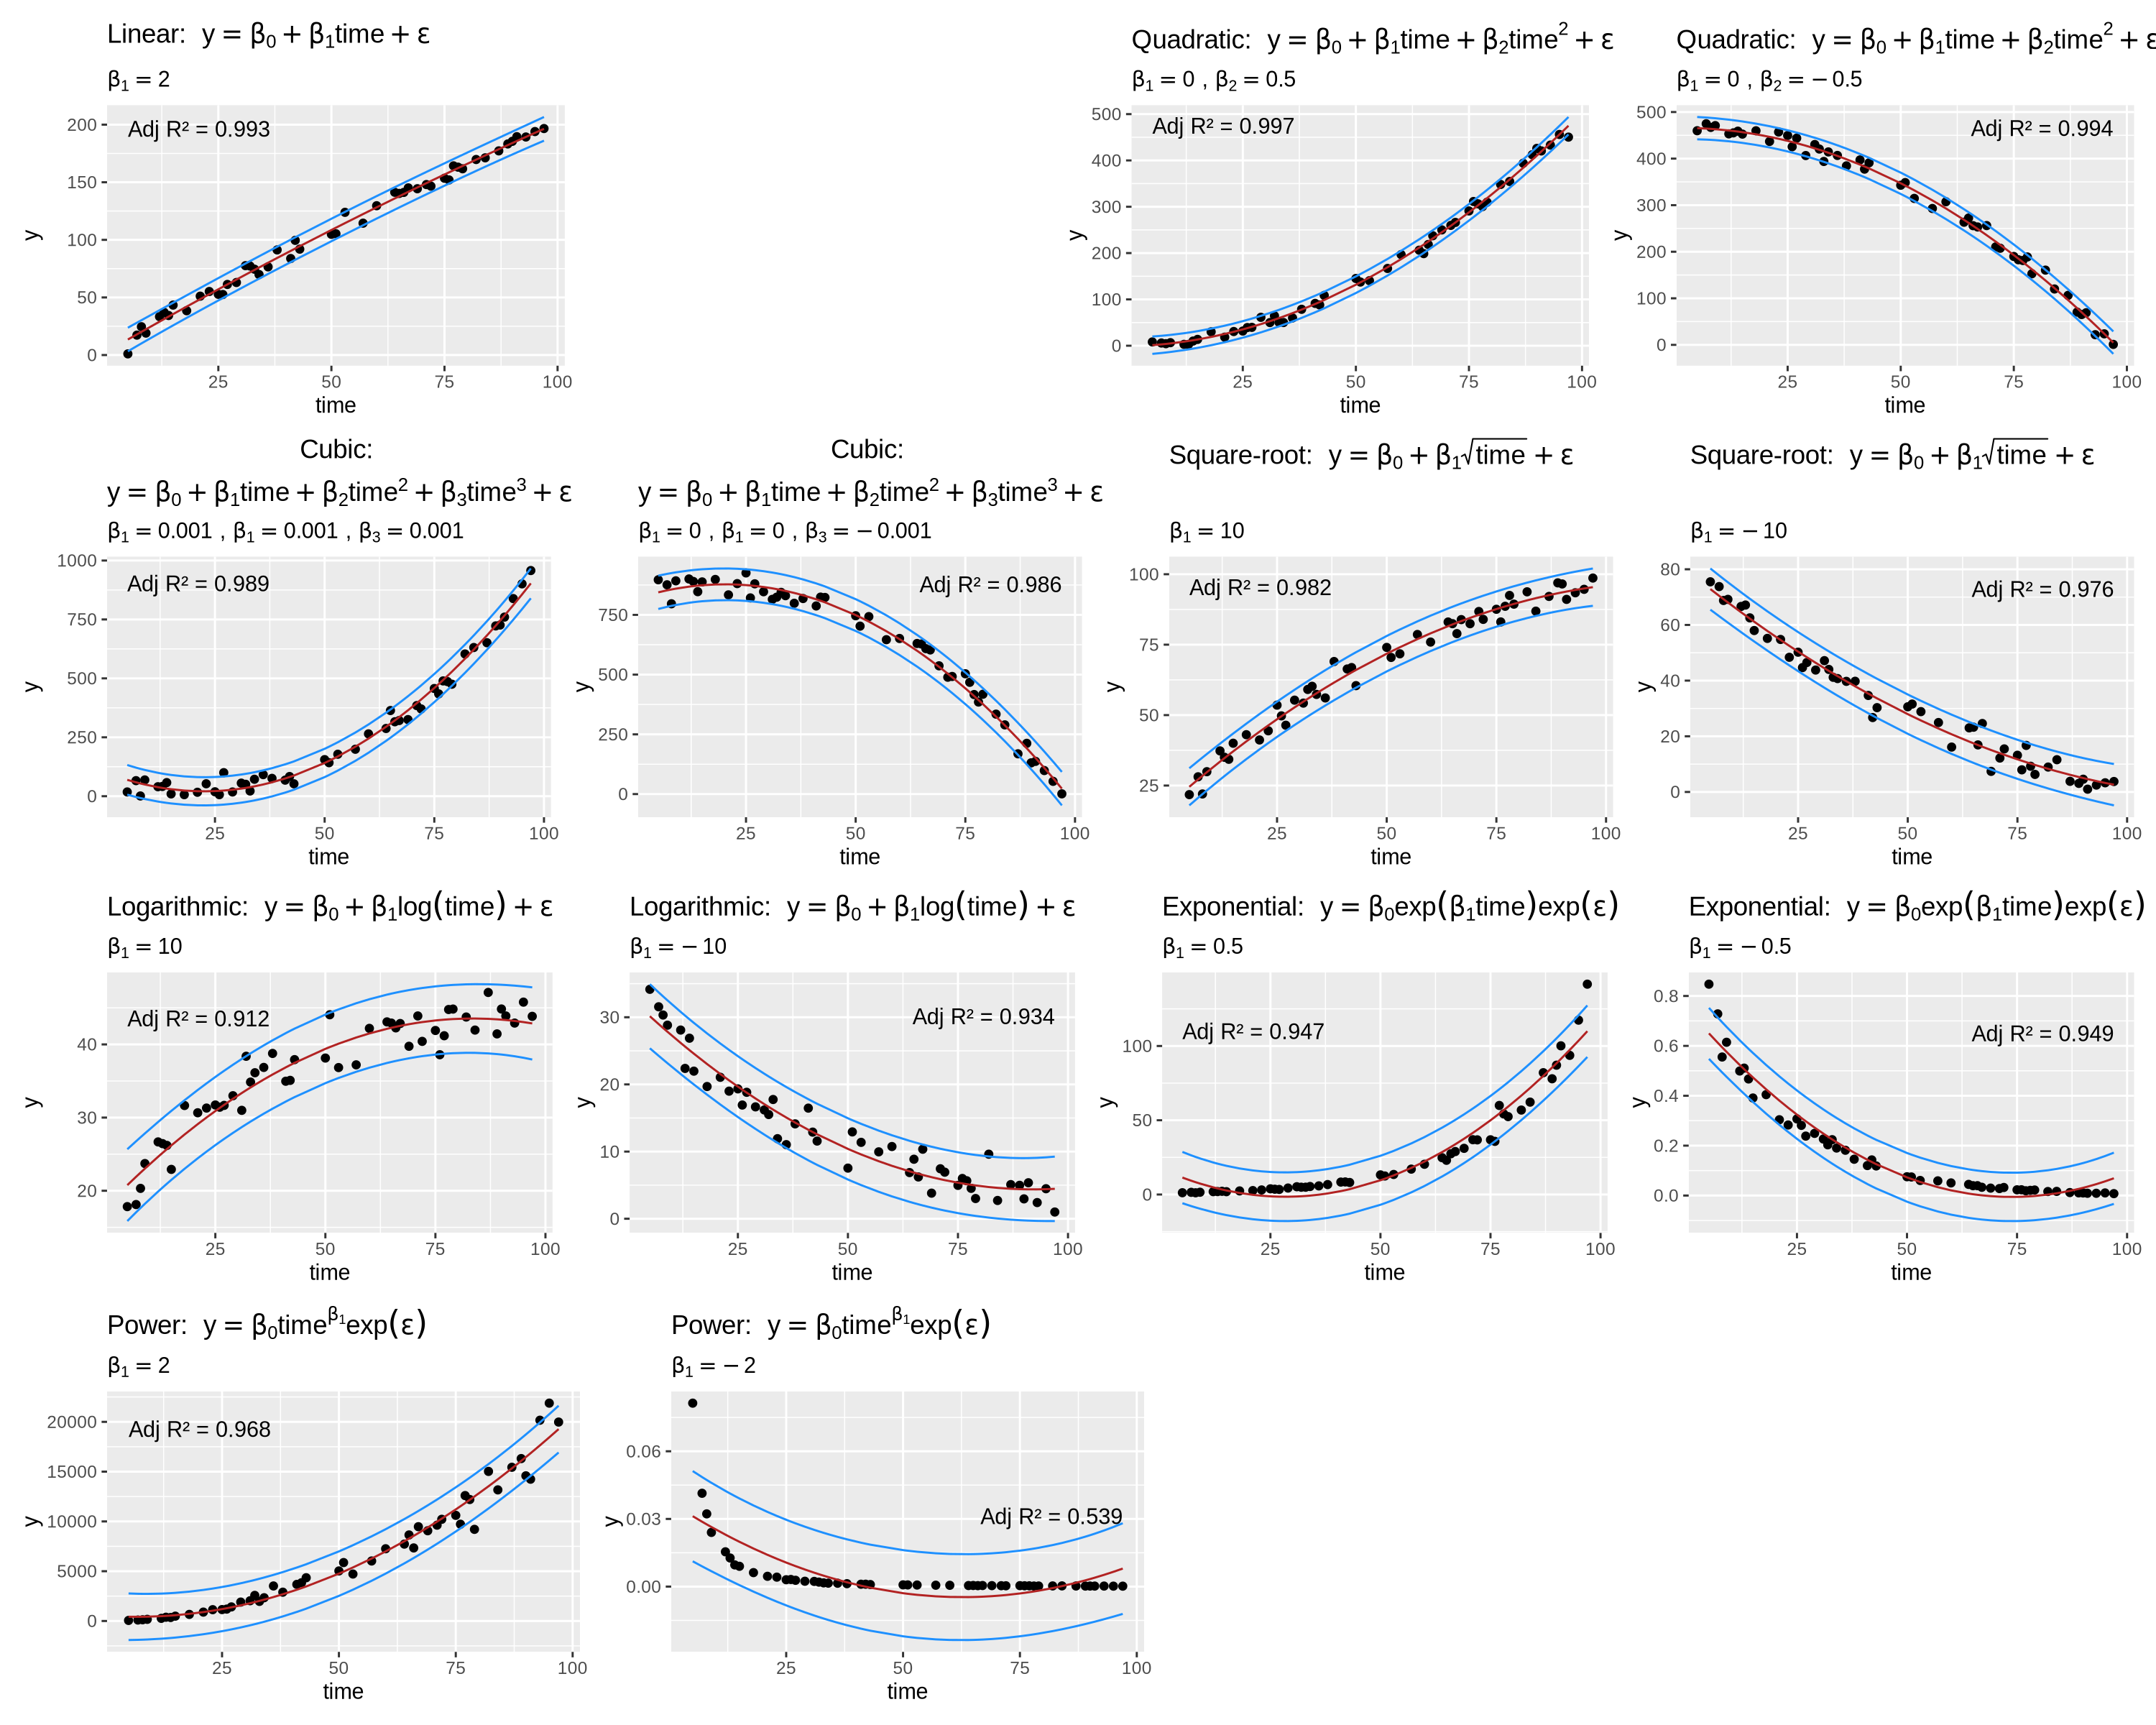

In [9]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Cubic model


In [10]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ time + I(time^2) + I(time^3), data = data_linear)
model_quadratic <- lm(y ~ time + I(time^2) + I(time^3), data = data_quadratic)
model_quadratic_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_quadratic_dec)
model_cubic <- lm(y ~ time + I(time^2) + I(time^3), data = data_cubic)
model_cubic_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_cubic_dec)
model_sqrt <- lm(y ~ time + I(time^2) + I(time^3), data = data_sqrt)
model_sqrt_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_sqrt_dec)
model_log <- lm(y ~ time + I(time^2) + I(time^3), data = data_log)
model_log_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_log_dec)
model_exp <- lm(y ~ time + I(time^2) + I(time^3), data = data_exp)
model_exp_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_exp_dec)
model_mult <- lm(y ~ time + I(time^2) + I(time^3), data = data_mult)
model_mult_dec <- lm(y ~ time + I(time^2) + I(time^3), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [11]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_cubic <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_cubic)

experiment_df <- cbind(experiment_df, Cubic_Adj_R_Squared = adj_r_squared_df_cubic$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9930411
2,Quadratic,0.9966288
3,Quadratic Dec,0.9942408
4,Cubic,0.9913957
5,Cubic Dec,0.9885879
6,Square-root,0.9824622


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared,Cubic_Adj_R_Squared
,<chr>,<dbl>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458,0.9930411
2,Quadratic,0.9519875,0.9965999,0.9966288
3,Quadratic Dec,0.9419899,0.9941927,0.9942408
4,Cubic,0.8456979,0.9888866,0.9913957
5,Cubic Dec,0.8611056,0.9857433,0.9885879
6,Square-root,0.9519183,0.9816979,0.9824622


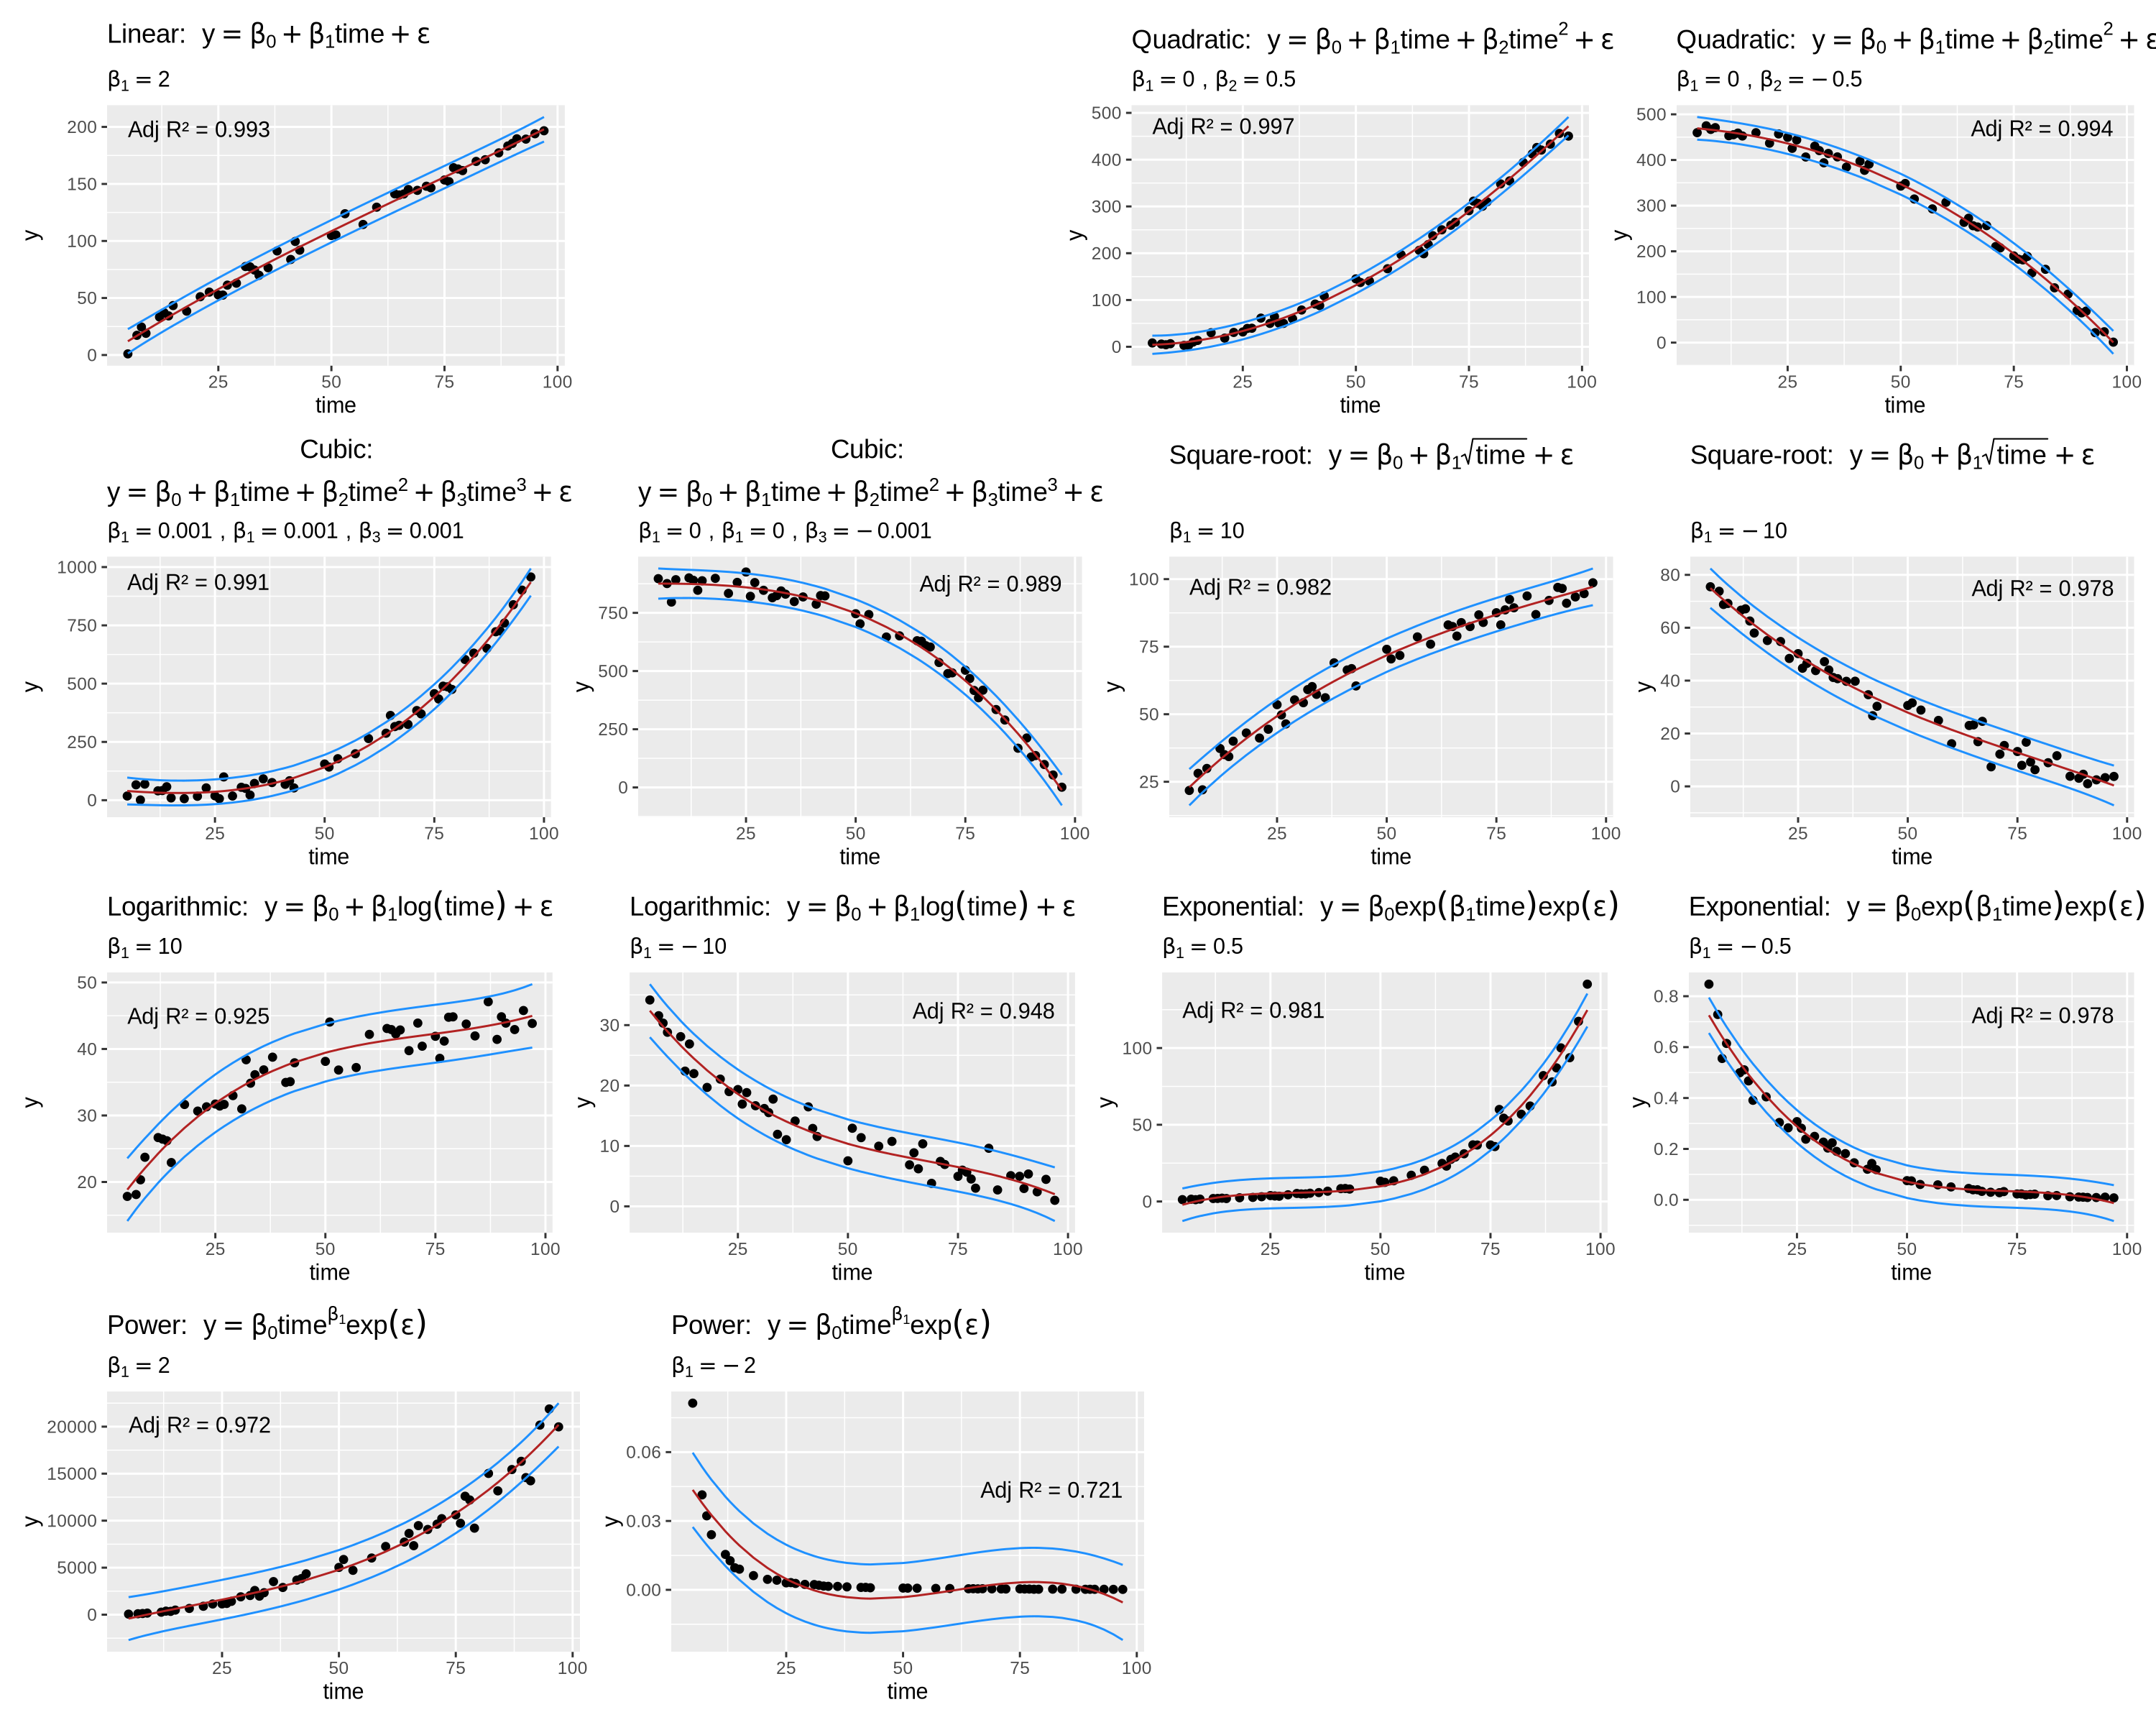

In [12]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Square root model

- The $\beta_1$ parameter shows how the response variable $y$ will change on average with increase of square root of $x$ by 1
- The square root represents the slow down in the change and might be suitable for cases of diminishing returns of scale in various real life problems
- The error is additive and normally distributed


In [13]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ I(sqrt(time)), data = data_linear)
model_quadratic <- lm(y ~ I(sqrt(time)), data = data_quadratic)
model_quadratic_dec <- lm(y ~ I(sqrt(time)), data = data_quadratic_dec)
model_cubic <- lm(y ~ I(sqrt(time)), data = data_cubic)
model_cubic_dec <- lm(y ~ I(sqrt(time)), data = data_cubic_dec)
model_sqrt <- lm(y ~ I(sqrt(time)), data = data_sqrt)
model_sqrt_dec <- lm(y ~ I(sqrt(time)), data = data_sqrt_dec)
model_log <- lm(y ~ I(sqrt(time)), data = data_log)
model_log_dec <- lm(y ~ I(sqrt(time)), data = data_log_dec)
model_exp <- lm(y ~ I(sqrt(time)), data = data_exp)
model_exp_dec <- lm(y ~ I(sqrt(time)), data = data_exp_dec)
model_mult <- lm(y ~ I(sqrt(time)), data = data_mult)
model_mult_dec <- lm(y ~ I(sqrt(time)), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [14]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_sqrt <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_sqrt)

experiment_df <- cbind(experiment_df, Sqrt_Adj_R_Squared = adj_r_squared_df_sqrt$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9792990
2,Quadratic,0.8695700
3,Quadratic Dec,0.8570633
4,Cubic,0.7315249
5,Cubic Dec,0.7523181
6,Square-root,0.9822922


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared,Cubic_Adj_R_Squared,Sqrt_Adj_R_Squared
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458,0.9930411,0.9792990
2,Quadratic,0.9519875,0.9965999,0.9966288,0.8695700
3,Quadratic Dec,0.9419899,0.9941927,0.9942408,0.8570633
4,Cubic,0.8456979,0.9888866,0.9913957,0.7315249
5,Cubic Dec,0.8611056,0.9857433,0.9885879,0.7523181
6,Square-root,0.9519183,0.9816979,0.9824622,0.9822922


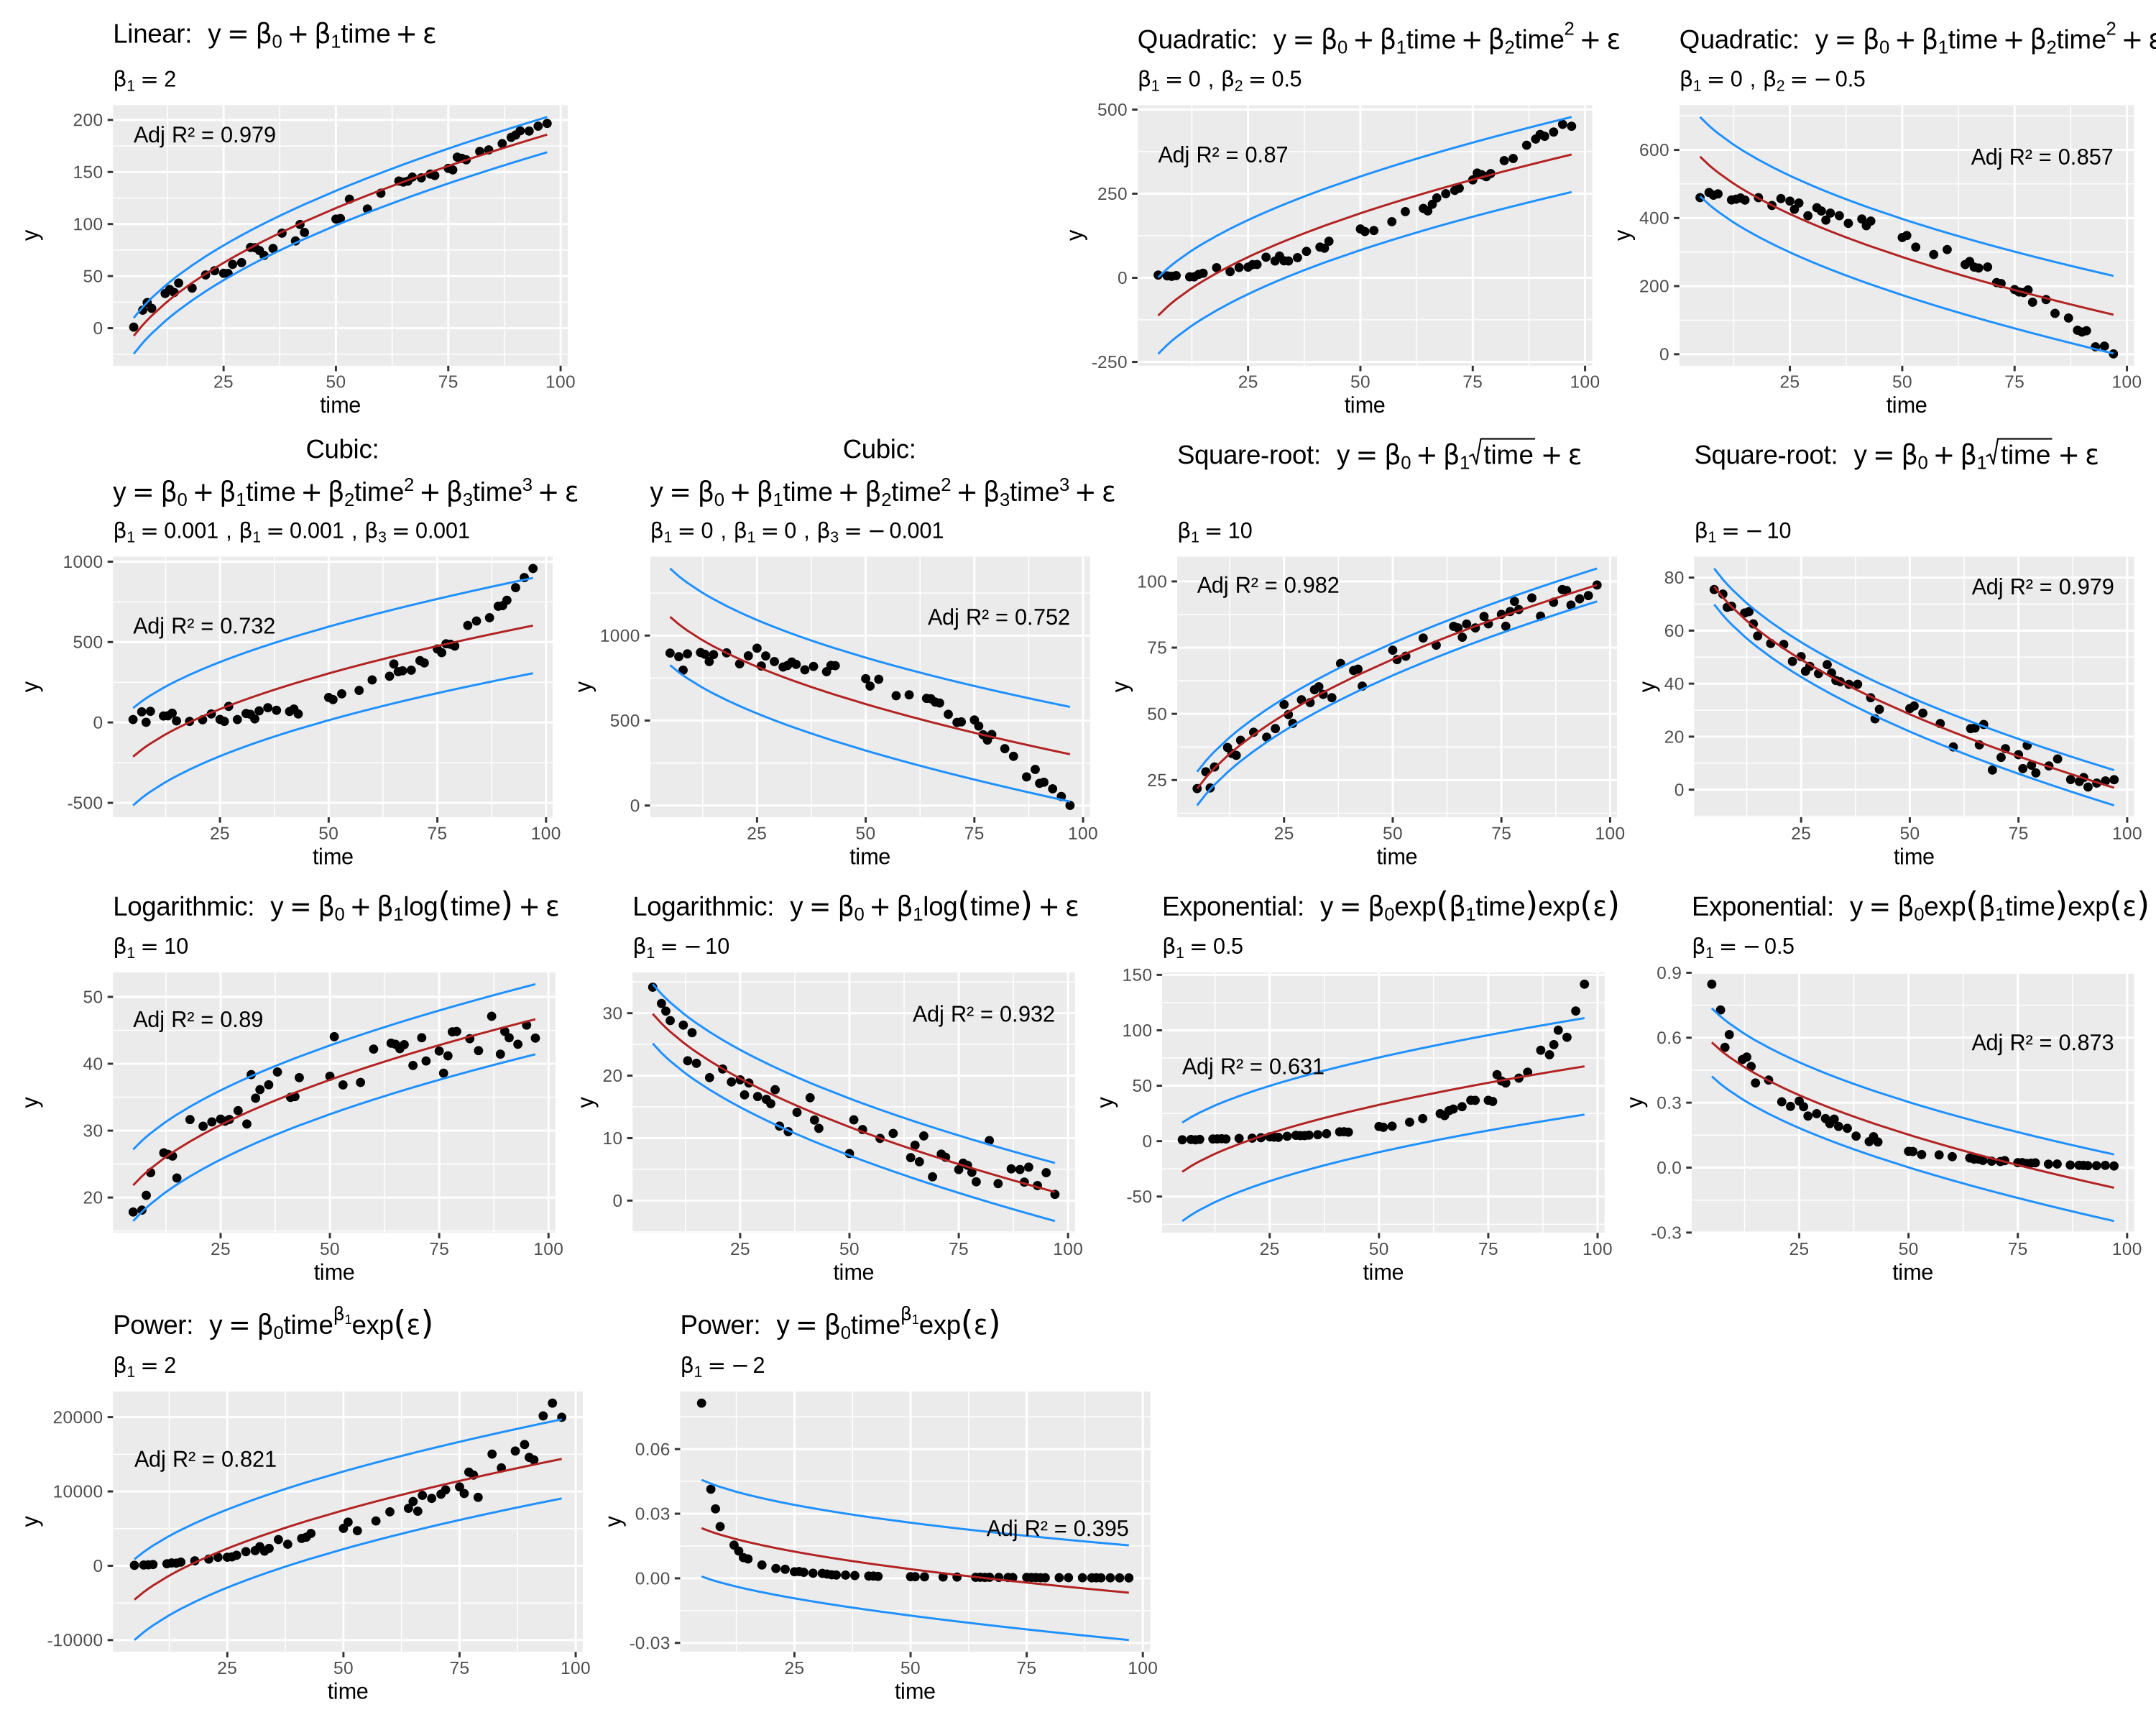

In [15]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Logarithmic model (AKA linear-log)

- The $\beta_1$ parameter regulates the direction and speed of change of a logarithmic transformed explanatory variable:
  - if $x$ increases by 1%, the response variable $y$ changes on average by $\beta_1 / 100$ units
- This model can capture non-linear relations with logarithmic growth or decline, depending on the value of $\beta_1$
- The error is additive and normally distributed


In [16]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ I(log(time)), data = data_linear)
model_quadratic <- lm(y ~ I(log(time)), data = data_quadratic)
model_quadratic_dec <- lm(y ~ I(log(time)), data = data_quadratic_dec)
model_cubic <- lm(y ~ I(log(time)), data = data_cubic)
model_cubic_dec <- lm(y ~ I(log(time)), data = data_cubic_dec)
model_sqrt <- lm(y ~ I(log(time)), data = data_sqrt)
model_sqrt_dec <- lm(y ~ I(log(time)), data = data_sqrt_dec)
model_log <- lm(y ~ I(log(time)), data = data_log)
model_log_dec <- lm(y ~ I(log(time)), data = data_log_dec)
model_exp <- lm(y ~ I(log(time)), data = data_exp)
model_exp_dec <- lm(y ~ I(log(time)), data = data_exp_dec)
model_mult <- lm(y ~ I(log(time)), data = data_mult)
model_mult_dec <- lm(y ~ I(log(time)), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [17]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_log <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_log)

experiment_df <- cbind(experiment_df, Log_Adj_R_Squared = adj_r_squared_df_log$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9042974
2,Quadratic,0.7294576
3,Quadratic Dec,0.7164767
4,Cubic,0.5754298
5,Cubic Dec,0.5995126
6,Square-root,0.9536408


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared,Cubic_Adj_R_Squared,Sqrt_Adj_R_Squared,Log_Adj_R_Squared
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458,0.9930411,0.9792990,0.9042974
2,Quadratic,0.9519875,0.9965999,0.9966288,0.8695700,0.7294576
3,Quadratic Dec,0.9419899,0.9941927,0.9942408,0.8570633,0.7164767
4,Cubic,0.8456979,0.9888866,0.9913957,0.7315249,0.5754298
5,Cubic Dec,0.8611056,0.9857433,0.9885879,0.7523181,0.5995126
6,Square-root,0.9519183,0.9816979,0.9824622,0.9822922,0.9536408


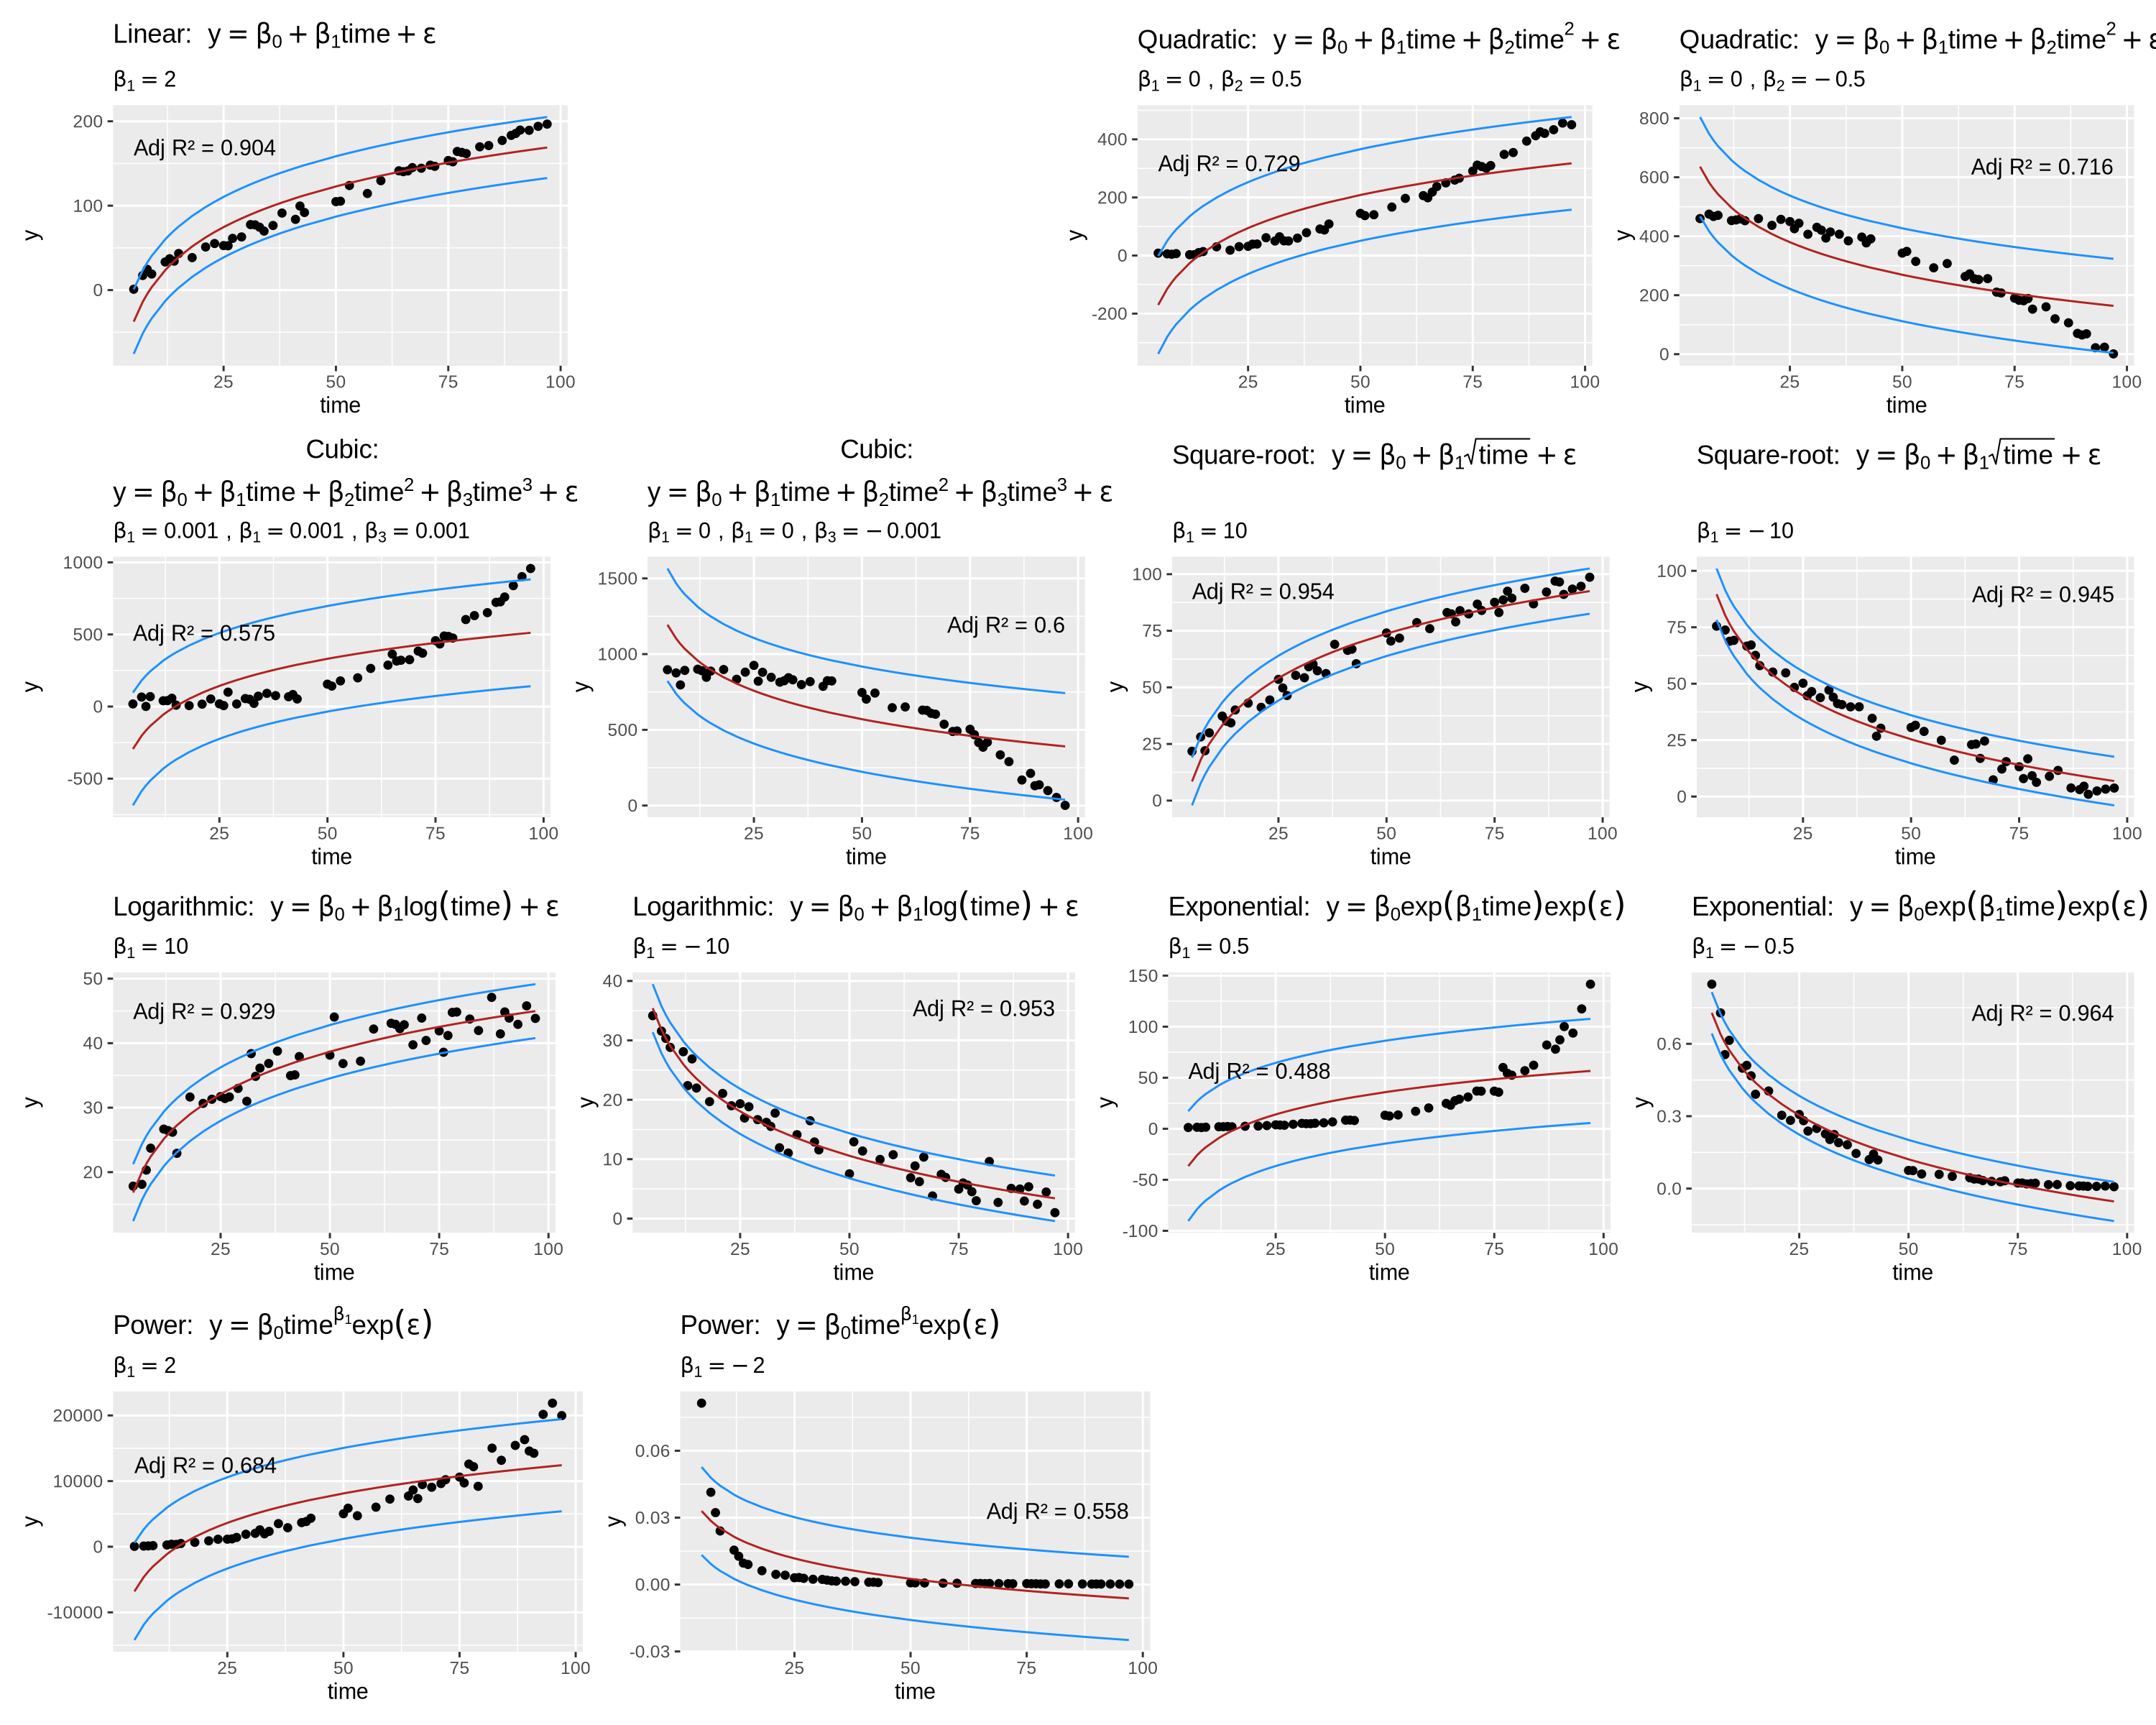

In [18]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Exponential model (AKA log-linear)

- The $\beta_1$ parameter controls the change of speed of growth/decline in the model:
  - if $x$ increases by 1 unit, the response variable $y$ changes on average by $(exp(\beta_1)-1)*100$%
- This model can capture non-linear relations with exponential growth or decline, depending on the value of $\beta_1$
- The error is multiplicative and log-normal distributed


In [19]:
# Apply linear models to each dataframe in the list
model_linear <- lm(log(y) ~ time, data = data_linear)
model_quadratic <- lm(log(y) ~ time, data = data_quadratic)
model_quadratic_dec <- lm(log(y) ~ time, data = data_quadratic_dec)
model_cubic <- lm(log(y) ~ time, data = data_cubic)
model_cubic_dec <- lm(log(y) ~ time, data = data_cubic_dec)
model_sqrt <- lm(log(y) ~ time, data = data_sqrt)
model_sqrt_dec <- lm(log(y) ~ time, data = data_sqrt_dec)
model_log <- lm(log(y) ~ time, data = data_log)
model_log_dec <- lm(log(y) ~ time, data = data_log_dec)
model_exp <- lm(log(y) ~ time, data = data_exp)
model_exp_dec <- lm(log(y) ~ time, data = data_exp_dec)
model_mult <- lm(log(y) ~ time, data = data_mult)
model_mult_dec <- lm(log(y) ~ time, data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- exp(predict(model_linear, newdata = data_linear, interval = "prediction"))
pred_quadratic <- exp(predict(model_quadratic, newdata = data_quadratic, interval = "prediction"))
pred_quadratic_dec <- exp(predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction"))
pred_cubic <- exp(predict(model_cubic, newdata = data_cubic, interval = "prediction"))
pred_cubic_dec <- exp(predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction"))
pred_sqrt <- exp(predict(model_sqrt, newdata = data_sqrt, interval = "prediction"))
pred_sqrt_dec <- exp(predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction"))
pred_log <- exp(predict(model_log, newdata = data_log, interval = "prediction"))
pred_log_dec <- exp(predict(model_log_dec, newdata = data_log_dec, interval = "prediction"))
pred_exp <- exp(predict(model_exp, newdata = data_exp, interval = "prediction"))
pred_exp_dec <- exp(predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction"))
pred_mult <- exp(predict(model_mult, newdata = data_mult, interval = "prediction"))
pred_mult_dec <- exp(predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction"))


In [20]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_exp <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_exp)

experiment_df <- cbind(experiment_df, Exp_Adj_R_Squared = adj_r_squared_df_exp$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.6626350
2,Quadratic,0.8845048
3,Quadratic Dec,0.5274353
4,Cubic,0.7921837
5,Cubic Dec,0.4175643
6,Square-root,0.8573203


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared,Cubic_Adj_R_Squared,Sqrt_Adj_R_Squared,Log_Adj_R_Squared,Exp_Adj_R_Squared
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458,0.9930411,0.9792990,0.9042974,0.6626350
2,Quadratic,0.9519875,0.9965999,0.9966288,0.8695700,0.7294576,0.8845048
3,Quadratic Dec,0.9419899,0.9941927,0.9942408,0.8570633,0.7164767,0.5274353
4,Cubic,0.8456979,0.9888866,0.9913957,0.7315249,0.5754298,0.7921837
5,Cubic Dec,0.8611056,0.9857433,0.9885879,0.7523181,0.5995126,0.4175643
6,Square-root,0.9519183,0.9816979,0.9824622,0.9822922,0.9536408,0.8573203


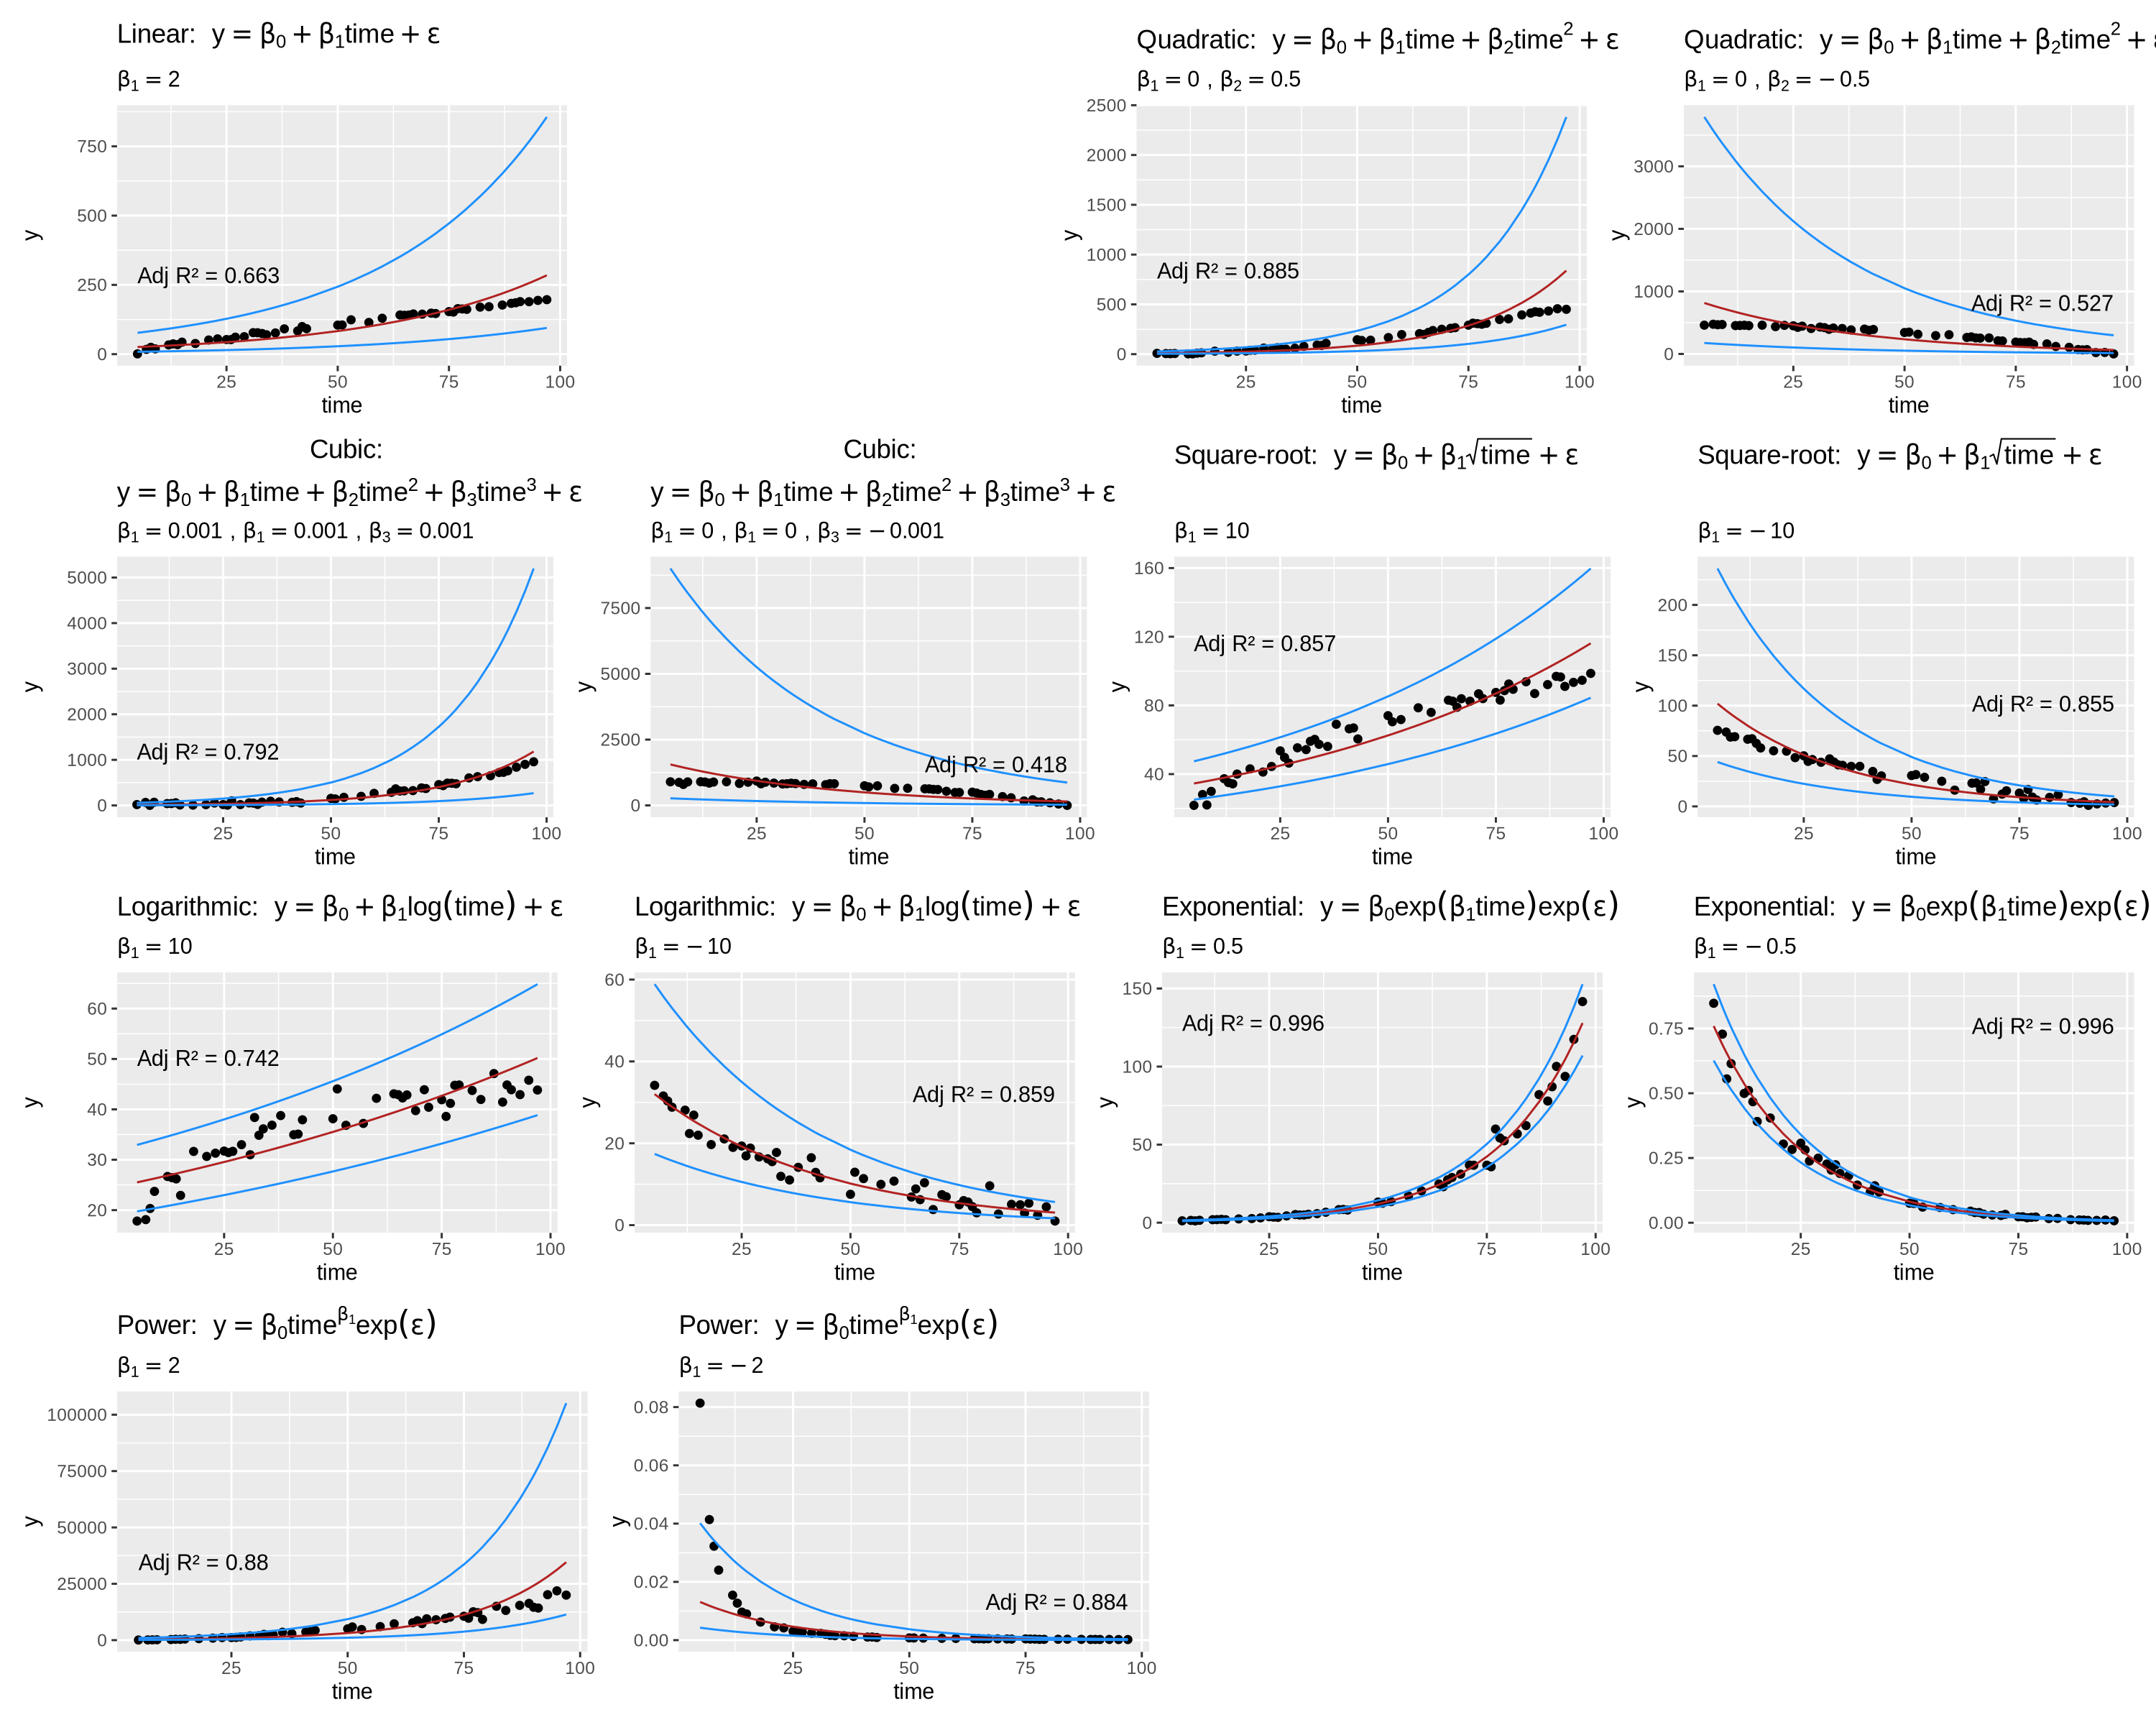

In [21]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Multiplicative/power model (AKA log-log)

- The $\beta_1$ parameter is interpreted as the elasticity:
  - if $x$ increases by 1%, the response variable $y$ changes on average by $\beta_1$%
- This model can capture non-linear relations with slowing down or accelerating changes, depending on the value of $\beta_1$
- The error is multiplicative and log-normal distributed


In [22]:
# Apply linear models to each dataframe in the list
model_linear <- lm(log(y) ~ I(log(time)), data = data_linear)
model_quadratic <- lm(log(y) ~ I(log(time)), data = data_quadratic)
model_quadratic_dec <- lm(log(y) ~ I(log(time)), data = data_quadratic_dec)
model_cubic <- lm(log(y) ~ I(log(time)), data = data_cubic)
model_cubic_dec <- lm(log(y) ~ I(log(time)), data = data_cubic_dec)
model_sqrt <- lm(log(y) ~ I(log(time)), data = data_sqrt)
model_sqrt_dec <- lm(log(y) ~ I(log(time)), data = data_sqrt_dec)
model_log <- lm(log(y) ~ I(log(time)), data = data_log)
model_log_dec <- lm(log(y) ~ I(log(time)), data = data_log_dec)
model_exp <- lm(log(y) ~ I(log(time)), data = data_exp)
model_exp_dec <- lm(log(y) ~ I(log(time)), data = data_exp_dec)
model_mult <- lm(log(y) ~ I(log(time)), data = data_mult)
model_mult_dec <- lm(log(y) ~ I(log(time)), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- exp(predict(model_linear, newdata = data_linear, interval = "prediction"))
pred_quadratic <- exp(predict(model_quadratic, newdata = data_quadratic, interval = "prediction"))
pred_quadratic_dec <- exp(predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction"))
pred_cubic <- exp(predict(model_cubic, newdata = data_cubic, interval = "prediction"))
pred_cubic_dec <- exp(predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction"))
pred_sqrt <- exp(predict(model_sqrt, newdata = data_sqrt, interval = "prediction"))
pred_sqrt_dec <- exp(predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction"))
pred_log <- exp(predict(model_log, newdata = data_log, interval = "prediction"))
pred_log_dec <- exp(predict(model_log_dec, newdata = data_log_dec, interval = "prediction"))
pred_exp <- exp(predict(model_exp, newdata = data_exp, interval = "prediction"))
pred_exp_dec <- exp(predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction"))
pred_mult <- exp(predict(model_mult, newdata = data_mult, interval = "prediction"))
pred_mult_dec <- exp(predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction"))


In [23]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_power <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_power)

experiment_df <- cbind(experiment_df, Power_Adj_R_Squared = adj_r_squared_df_power$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.8493625
2,Quadratic,0.9391794
3,Quadratic Dec,0.3297566
4,Cubic,0.6797694
5,Cubic Dec,0.2437380
6,Square-root,0.9791648


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared,Cubic_Adj_R_Squared,Sqrt_Adj_R_Squared,Log_Adj_R_Squared,Exp_Adj_R_Squared,Power_Adj_R_Squared
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458,0.9930411,0.9792990,0.9042974,0.6626350,0.8493625
2,Quadratic,0.9519875,0.9965999,0.9966288,0.8695700,0.7294576,0.8845048,0.9391794
3,Quadratic Dec,0.9419899,0.9941927,0.9942408,0.8570633,0.7164767,0.5274353,0.3297566
4,Cubic,0.8456979,0.9888866,0.9913957,0.7315249,0.5754298,0.7921837,0.6797694
5,Cubic Dec,0.8611056,0.9857433,0.9885879,0.7523181,0.5995126,0.4175643,0.2437380
6,Square-root,0.9519183,0.9816979,0.9824622,0.9822922,0.9536408,0.8573203,0.9791648


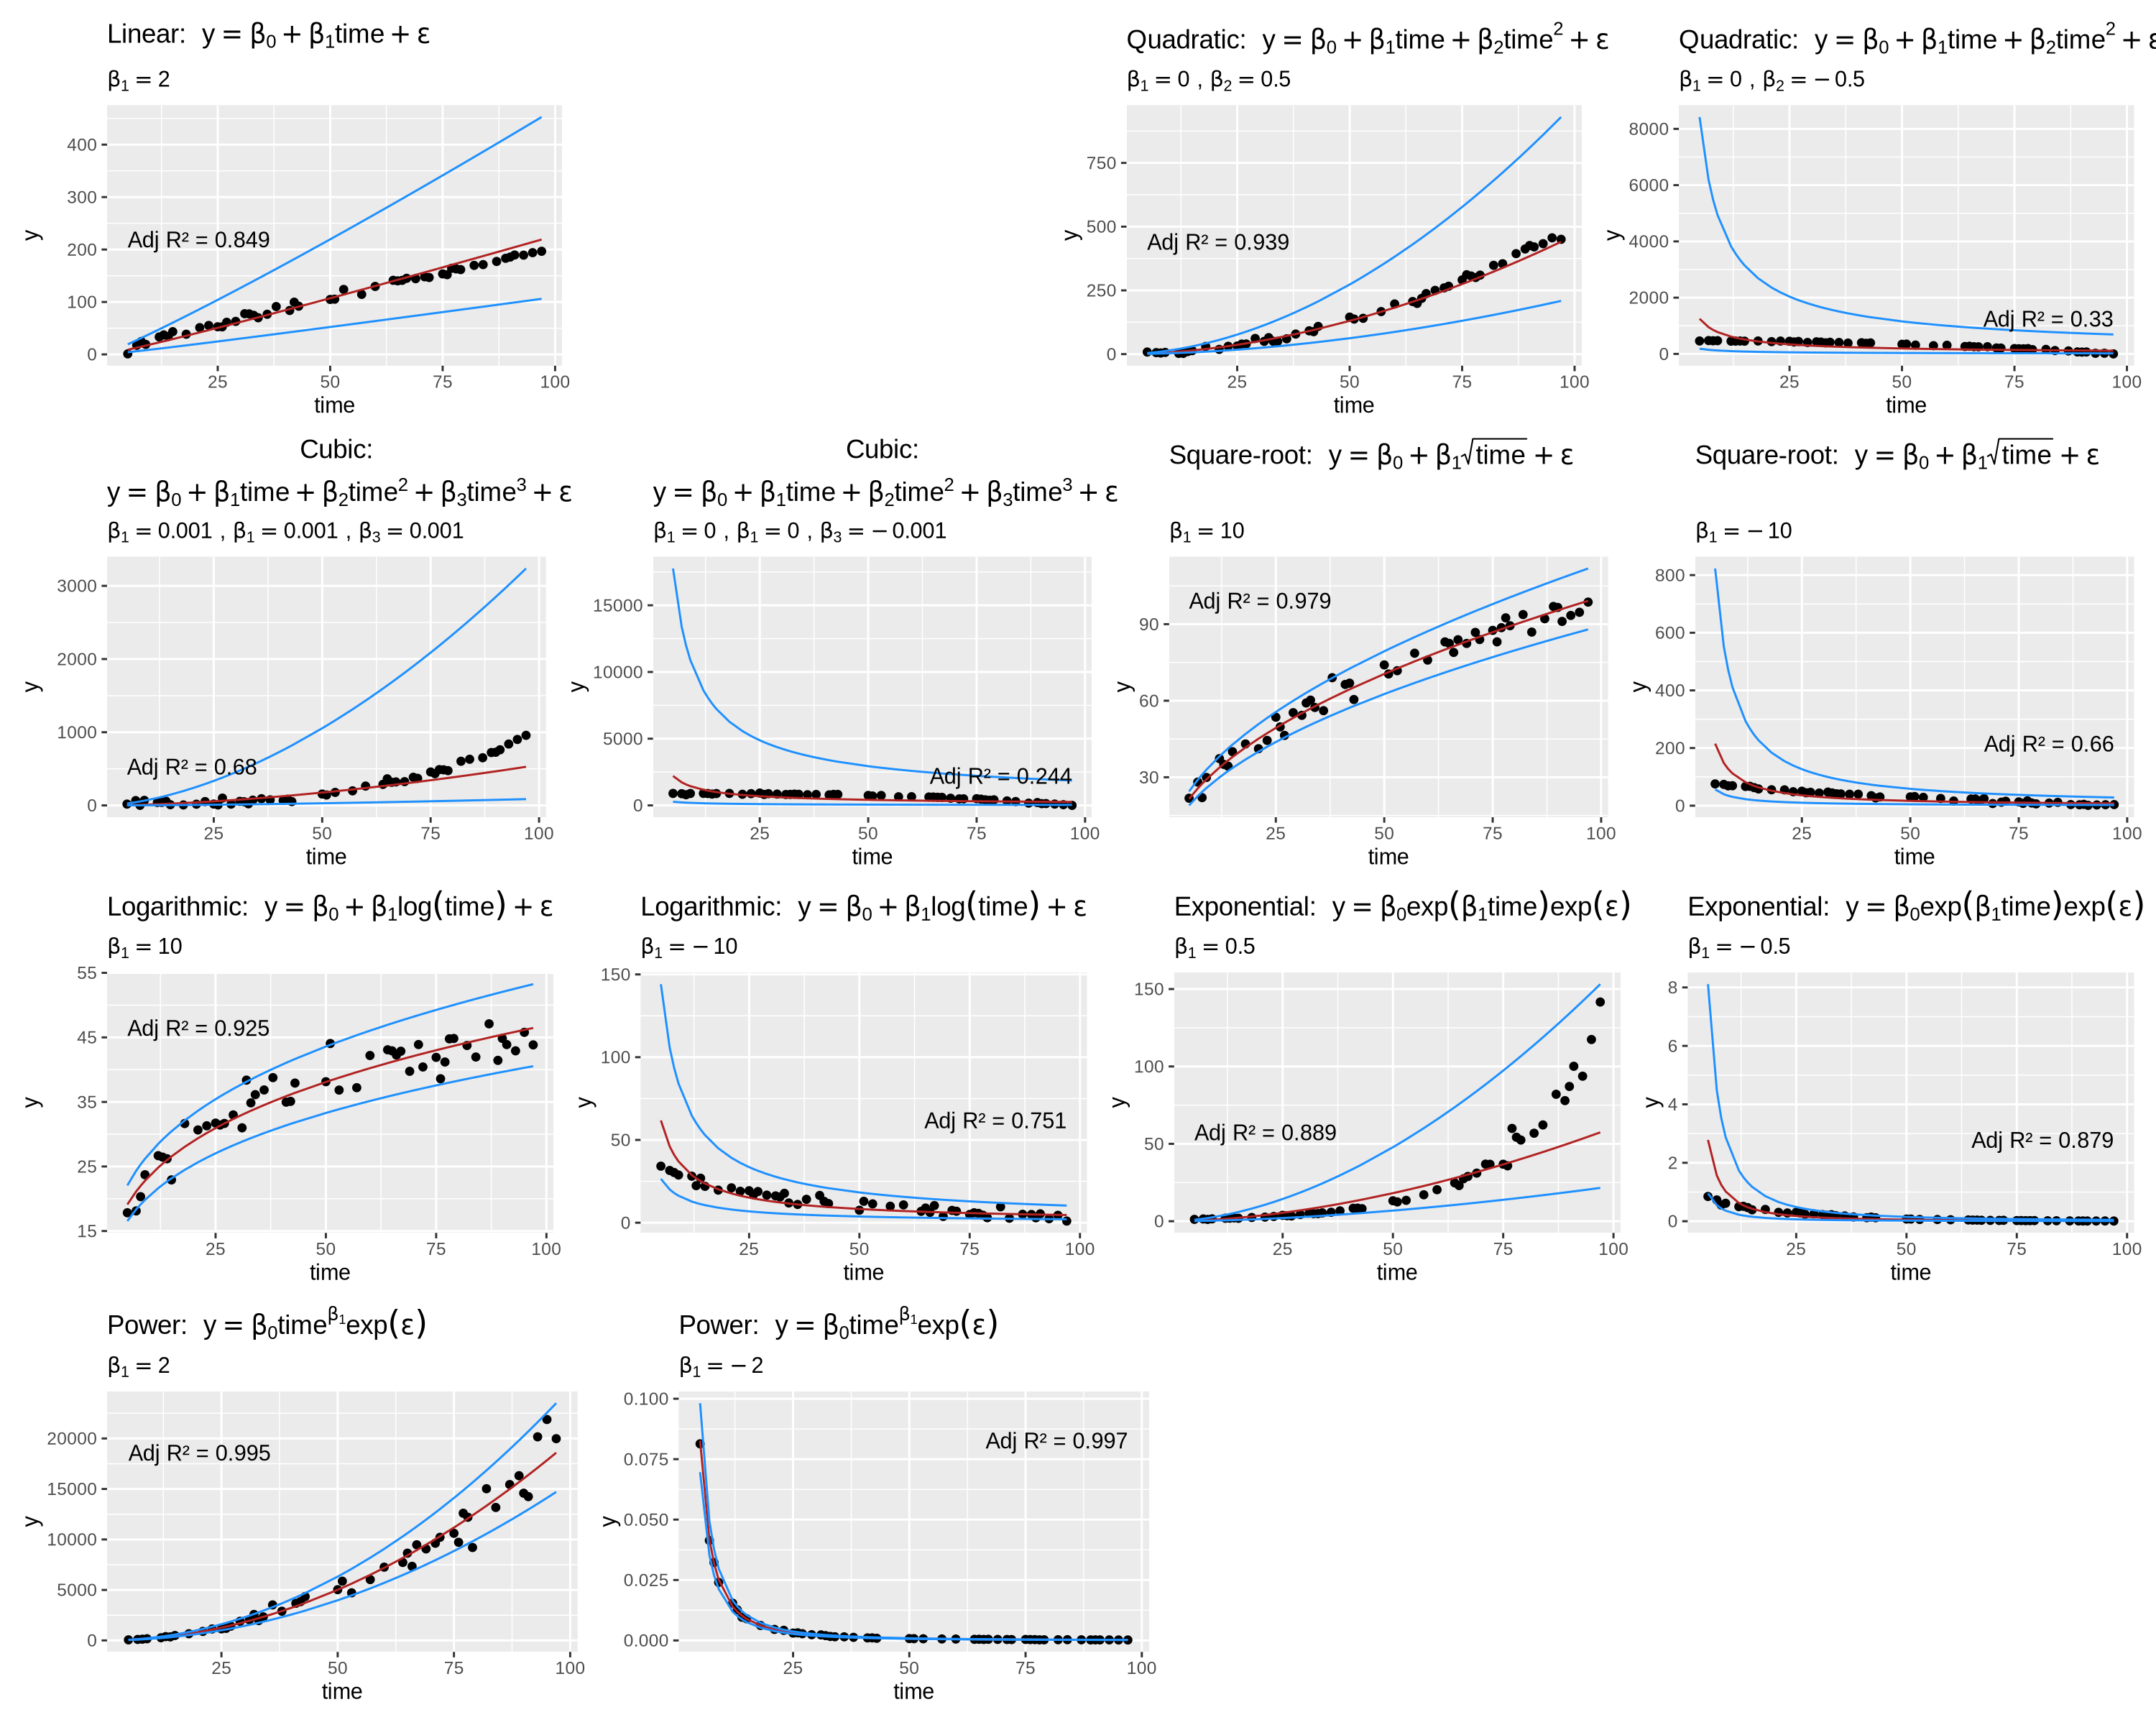

In [24]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


# Spline model

- Here I am fitting a spline regression with df=4, which is a cubic spline (to be comparable to the cubic model)
- I usually prefer df=5


In [25]:
# Apply linear models to each dataframe in the list
model_linear <- lm(y ~ bs(time, df = 4), data = data_linear)
model_quadratic <- lm(y ~ bs(time, df = 4), data = data_quadratic)
model_quadratic_dec <- lm(y ~ bs(time, df = 4), data = data_quadratic_dec)
model_cubic <- lm(y ~ bs(time, df = 4), data = data_cubic)
model_cubic_dec <- lm(y ~ bs(time, df = 4), data = data_cubic_dec)
model_sqrt <- lm(y ~ bs(time, df = 4), data = data_sqrt)
model_sqrt_dec <- lm(y ~ bs(time, df = 4), data = data_sqrt_dec)
model_log <- lm(y ~ bs(time, df = 4), data = data_log)
model_log_dec <- lm(y ~ bs(time, df = 4), data = data_log_dec)
model_exp <- lm(y ~ bs(time, df = 4), data = data_exp)
model_exp_dec <- lm(y ~ bs(time, df = 4), data = data_exp_dec)
model_mult <- lm(y ~ bs(time, df = 4), data = data_mult)
model_mult_dec <- lm(y ~ bs(time, df = 4), data = data_mult_dec)

# Predict with interval="prediction" for each model
pred_linear <- predict(model_linear, newdata = data_linear, interval = "prediction")
pred_quadratic <- predict(model_quadratic, newdata = data_quadratic, interval = "prediction")
pred_quadratic_dec <- predict(model_quadratic_dec, newdata = data_quadratic_dec, interval = "prediction")
pred_cubic <- predict(model_cubic, newdata = data_cubic, interval = "prediction")
pred_cubic_dec <- predict(model_cubic_dec, newdata = data_cubic_dec, interval = "prediction")
pred_sqrt <- predict(model_sqrt, newdata = data_sqrt, interval = "prediction")
pred_sqrt_dec <- predict(model_sqrt_dec, newdata = data_sqrt_dec, interval = "prediction")
pred_log <- predict(model_log, newdata = data_log, interval = "prediction")
pred_log_dec <- predict(model_log_dec, newdata = data_log_dec, interval = "prediction")
pred_exp <- predict(model_exp, newdata = data_exp, interval = "prediction")
pred_exp_dec <- predict(model_exp_dec, newdata = data_exp_dec, interval = "prediction")
pred_mult <- predict(model_mult, newdata = data_mult, interval = "prediction")
pred_mult_dec <- predict(model_mult_dec, newdata = data_mult_dec, interval = "prediction")


In [26]:
# Extract adjusted R-squared for each model
adj_r_squared_linear <- summary(model_linear)$adj.r.squared
adj_r_squared_quadratic <- summary(model_quadratic)$adj.r.squared
adj_r_squared_quadratic_dec <- summary(model_quadratic_dec)$adj.r.squared
adj_r_squared_cubic <- summary(model_cubic)$adj.r.squared
adj_r_squared_cubic_dec <- summary(model_cubic_dec)$adj.r.squared
adj_r_squared_sqrt <- summary(model_sqrt)$adj.r.squared
adj_r_squared_sqrt_dec <- summary(model_sqrt_dec)$adj.r.squared
adj_r_squared_log <- summary(model_log)$adj.r.squared
adj_r_squared_log_dec <- summary(model_log_dec)$adj.r.squared
adj_r_squared_exp <- summary(model_exp)$adj.r.squared
adj_r_squared_exp_dec <- summary(model_exp_dec)$adj.r.squared
adj_r_squared_mult <- summary(model_mult)$adj.r.squared
adj_r_squared_mult_dec <- summary(model_mult_dec)$adj.r.squared

# Create a dataframe with all the adjusted R-squared values
adj_r_squared_df_spline <- data.frame(
    Model = c(
        "Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec",
        "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec",
        "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec"
    ),
    Adj_R_Squared = c(
        adj_r_squared_linear, adj_r_squared_quadratic, adj_r_squared_quadratic_dec,
        adj_r_squared_cubic, adj_r_squared_cubic_dec, adj_r_squared_sqrt,
        adj_r_squared_sqrt_dec, adj_r_squared_log, adj_r_squared_log_dec,
        adj_r_squared_exp, adj_r_squared_exp_dec, adj_r_squared_mult,
        adj_r_squared_mult_dec
    )
)

head(adj_r_squared_df_spline)

experiment_df <- cbind(experiment_df, Spline_Adj_R_Squared = adj_r_squared_df_spline$Adj_R_Squared)
head(experiment_df)


,Model,Adj_R_Squared
,<chr>,<dbl>
1,Linear,0.9929393
2,Quadratic,0.9966013
3,Quadratic Dec,0.9942133
4,Cubic,0.9913794
5,Cubic Dec,0.9883583
6,Square-root,0.9821782


,Model,Linear_Adj_R_Squared,Quadratic_Adj_R_Squared,Cubic_Adj_R_Squared,Sqrt_Adj_R_Squared,Log_Adj_R_Squared,Exp_Adj_R_Squared,Power_Adj_R_Squared,Spline_Adj_R_Squared
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Linear,0.9922407,0.9930458,0.9930411,0.9792990,0.9042974,0.6626350,0.8493625,0.9929393
2,Quadratic,0.9519875,0.9965999,0.9966288,0.8695700,0.7294576,0.8845048,0.9391794,0.9966013
3,Quadratic Dec,0.9419899,0.9941927,0.9942408,0.8570633,0.7164767,0.5274353,0.3297566,0.9942133
4,Cubic,0.8456979,0.9888866,0.9913957,0.7315249,0.5754298,0.7921837,0.6797694,0.9913794
5,Cubic Dec,0.8611056,0.9857433,0.9885879,0.7523181,0.5995126,0.4175643,0.2437380,0.9883583
6,Square-root,0.9519183,0.9816979,0.9824622,0.9822922,0.9536408,0.8573203,0.9791648,0.9821782


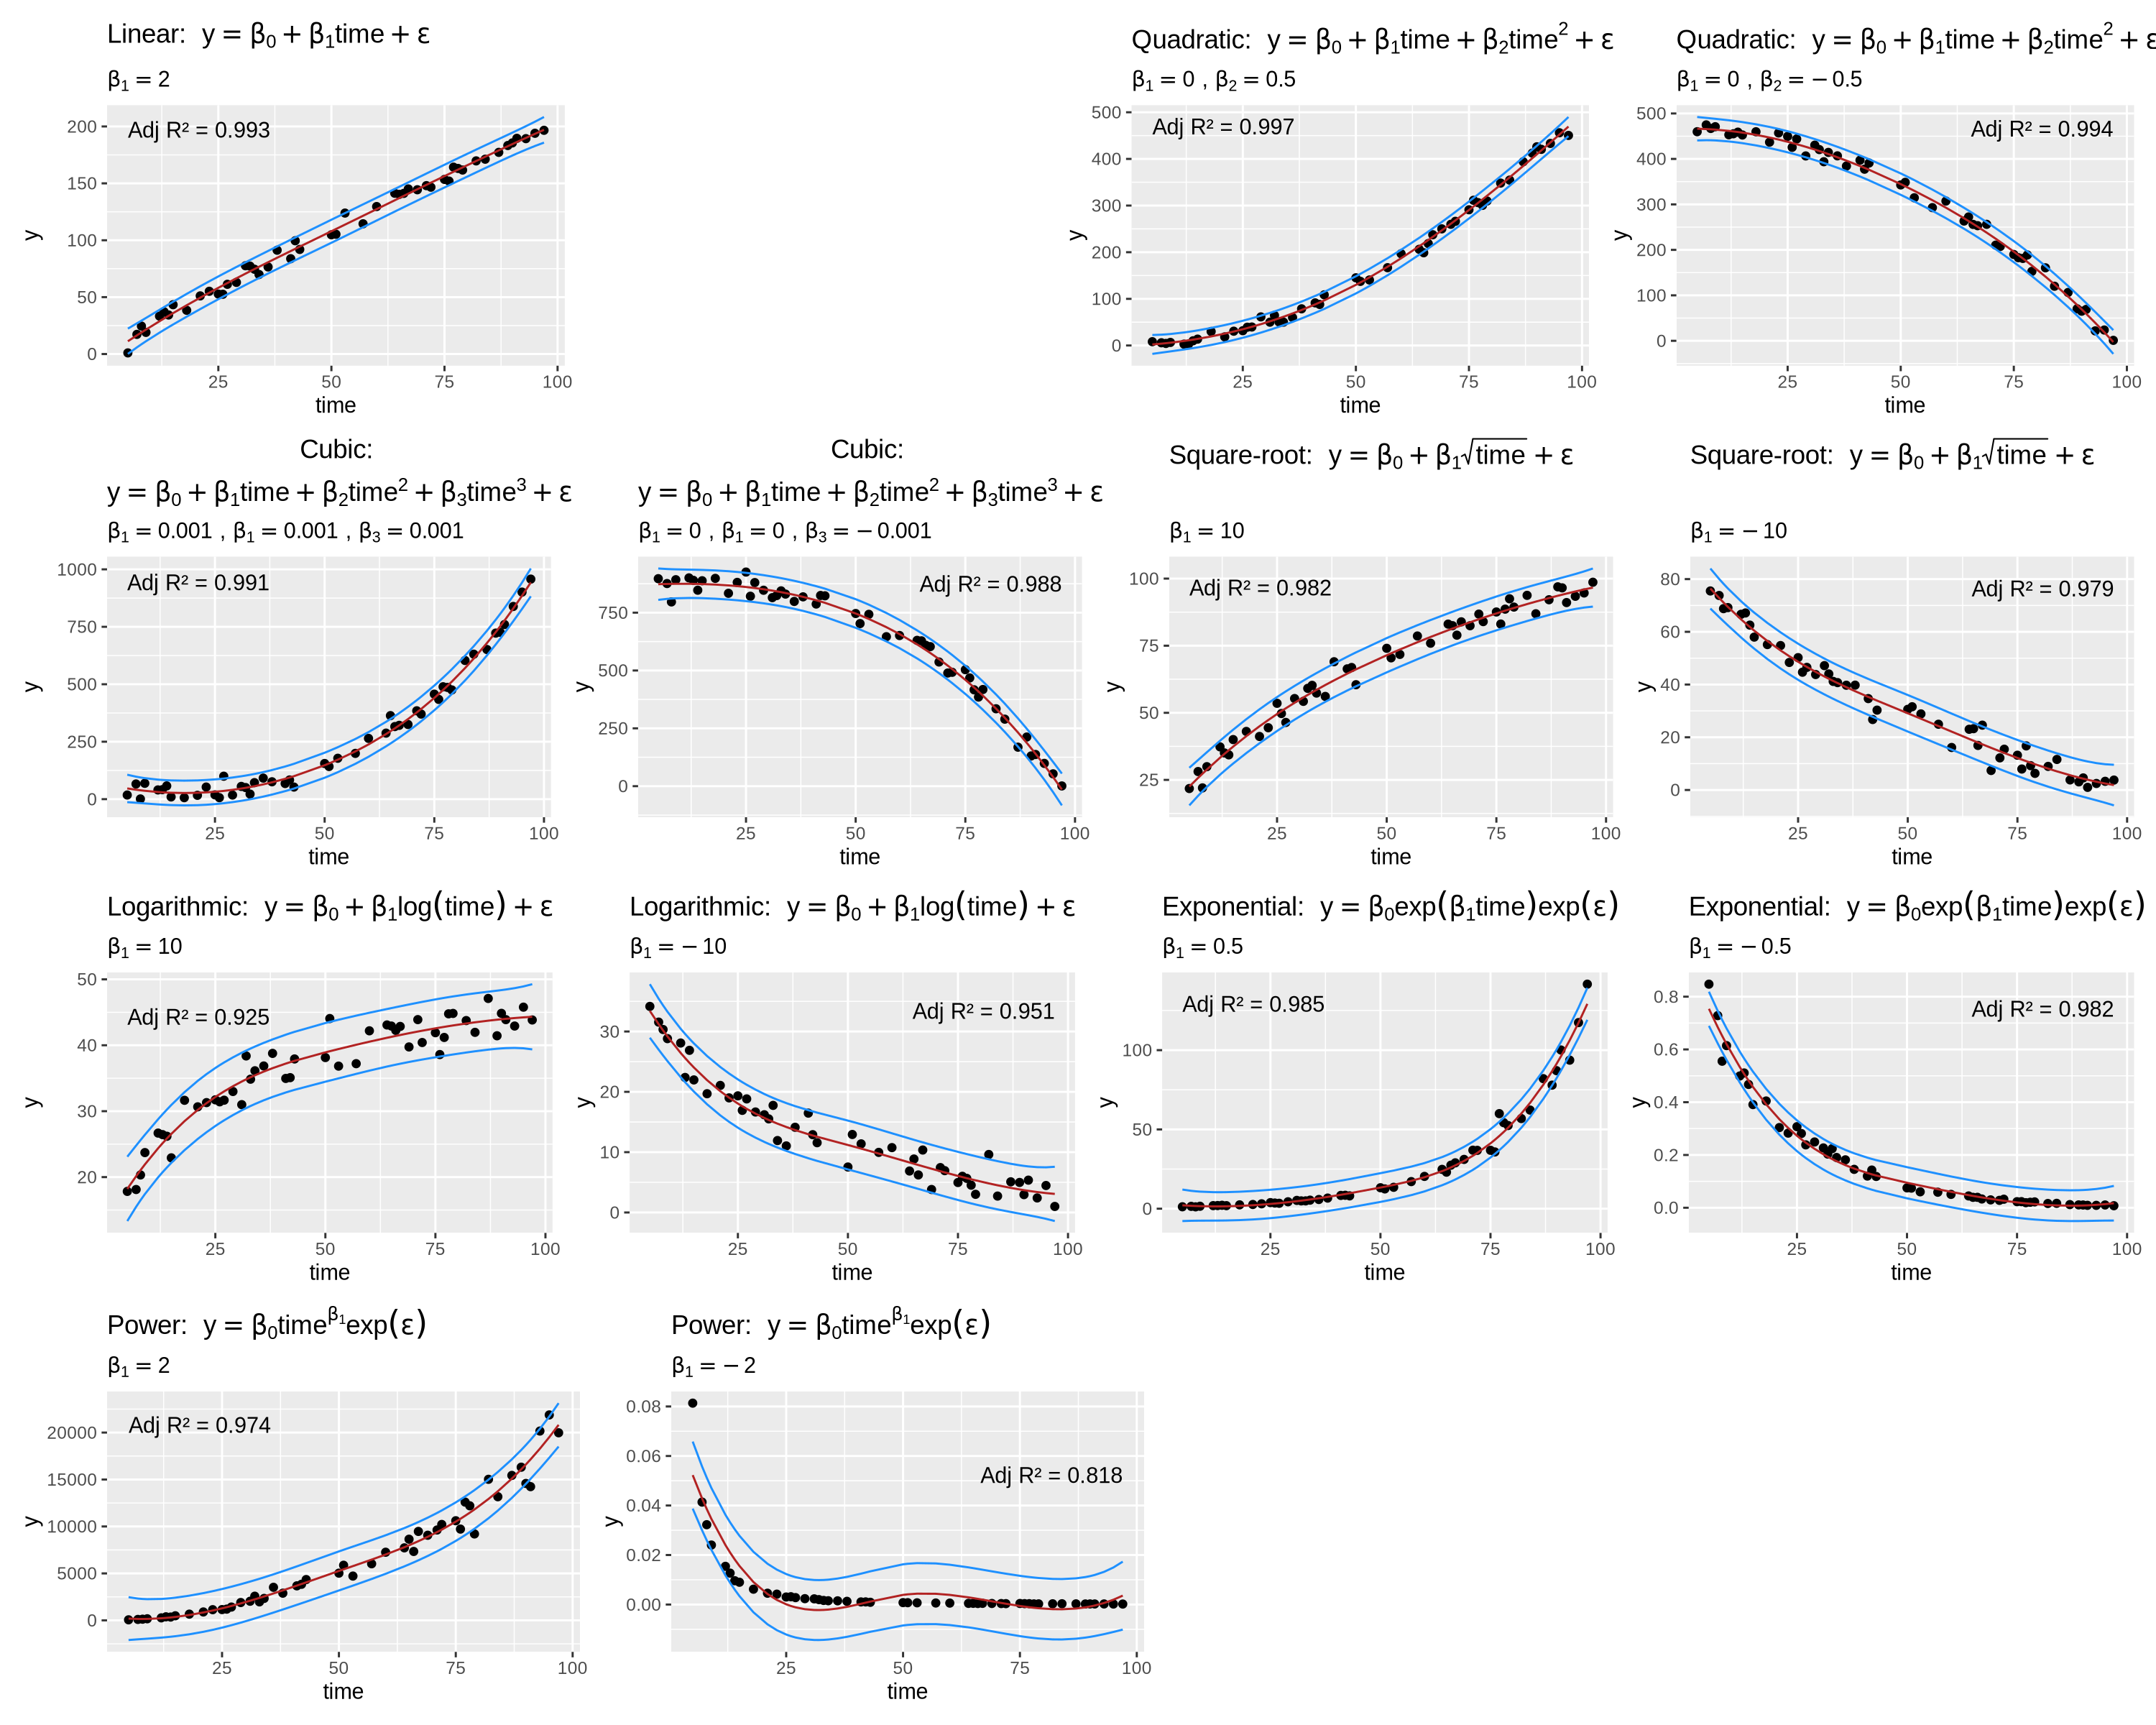

In [27]:
# Add prediction lines to each plot
plot_linear_pred <- plot_linear +
    geom_line(aes(x = time, y = pred_linear[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_linear[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_linear[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_linear[, 1]), label = paste("Adj R² =", round(adj_r_squared_linear, 3)), hjust = 0)

plot_quadratic_pred <- plot_quadratic +
    geom_line(aes(x = time, y = pred_quadratic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_quadratic[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic, 3)), hjust = 0)

plot_quadratic_dec_pred <- plot_quadratic_dec +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_quadratic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_quadratic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_quadratic_dec, 3)), hjust = 1)

plot_cubic_pred <- plot_cubic +
    geom_line(aes(x = time, y = pred_cubic[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_cubic[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic, 3)), hjust = 0)

plot_cubic_dec_pred <- plot_cubic_dec +
    geom_line(aes(x = time, y = pred_cubic_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_cubic_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_cubic_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_cubic_dec, 3)), hjust = 1)

plot_sqrt_pred <- plot_sqrt +
    geom_line(aes(x = time, y = pred_sqrt[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_sqrt[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt, 3)), hjust = 0)

plot_sqrt_dec_pred <- plot_sqrt_dec +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_sqrt_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_sqrt_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_sqrt_dec, 3)), hjust = 1)

plot_log_pred <- plot_log +
    geom_line(aes(x = time, y = pred_log[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_log[, 1]), label = paste("Adj R² =", round(adj_r_squared_log, 3)), hjust = 0)

plot_log_dec_pred <- plot_log_dec +
    geom_line(aes(x = time, y = pred_log_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_log_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_log_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_log_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_log_dec, 3)), hjust = 1)

plot_exp_pred <- plot_exp +
    geom_line(aes(x = time, y = pred_exp[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_exp[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp, 3)), hjust = 0)

plot_exp_dec_pred <- plot_exp_dec +
    geom_line(aes(x = time, y = pred_exp_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_exp_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_exp_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_exp_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_exp_dec, 3)), hjust = 1)

plot_mult_pred <- plot_mult +
    geom_line(aes(x = time, y = pred_mult[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult[, 3]), color = "dodgerblue") +
    annotate("text", x = min(time), y = max(pred_mult[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult, 3)), hjust = 0)

plot_mult_dec_pred <- plot_mult_dec +
    geom_line(aes(x = time, y = pred_mult_dec[, 1]), color = "firebrick") +
    geom_line(aes(x = time, y = pred_mult_dec[, 2]), color = "dodgerblue") +
    geom_line(aes(x = time, y = pred_mult_dec[, 3]), color = "dodgerblue") +
    annotate("text", x = max(time), y = max(pred_mult_dec[, 1]), label = paste("Adj R² =", round(adj_r_squared_mult_dec, 3)), hjust = 1)

# Combine all plots using patchwork
(plot_linear_pred | plot_spacer() | plot_quadratic_pred | plot_quadratic_dec_pred) /
    (plot_cubic_pred | plot_cubic_dec_pred | plot_sqrt_pred | plot_sqrt_dec_pred) /
    (plot_log_pred | plot_log_dec_pred | plot_exp_pred | plot_exp_dec_pred) /
    (plot_mult_pred | plot_mult_dec_pred | plot_spacer() | plot_spacer())


## Notes

- A spline regression fits well basically all models
- But cannot model the errors so well when the errors are multiplicative
- Also, it will probably predict points outside the range in the models in where the change over time approaches 0


# Compare all models


In [28]:
colnames(experiment_df) <- gsub("_Adj_R_Squared$", "", colnames(experiment_df))
experiment_df


Model,Linear,Quadratic,Cubic,Sqrt,Log,Exp,Power,Spline
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Linear,0.9922407,0.9930458,0.9930411,0.9792990,0.9042974,0.6626350,0.8493625,0.9929393
Quadratic,0.9519875,0.9965999,0.9966288,0.8695700,0.7294576,0.8845048,0.9391794,0.9966013
Quadratic Dec,0.9419899,0.9941927,0.9942408,0.8570633,0.7164767,0.5274353,0.3297566,0.9942133
Cubic,0.8456979,0.9888866,0.9913957,0.7315249,0.5754298,0.7921837,0.6797694,0.9913794
Cubic Dec,0.8611056,0.9857433,0.9885879,0.7523181,0.5995126,0.4175643,0.2437380,0.9883583
Square-root,0.9519183,0.9816979,0.9824622,0.9822922,0.9536408,0.8573203,0.9791648,0.9821782
Square-root Dec,0.9552409,0.9764600,0.9779887,0.9793278,0.9449730,0.8548653,0.6595827,0.9785794
Logarithmic,0.8120986,0.9116310,0.9246512,0.8902979,0.9294009,0.7423180,0.9250134,0.9246721
Logarithmic Dec,0.8673094,0.9337671,0.9482311,0.9316333,0.9530370,0.8593643,0.7505074,0.9506528


In [29]:
summary_df <- data.frame(
    Model_Type = colnames(experiment_df)[-1],
    Mean = colMeans(experiment_df[, -1]),
    SD = apply(experiment_df[, -1], 2, sd)
)
summary_df %>% arrange(desc(Mean))


,Model_Type,Mean,SD
,<chr>,<dbl>,<dbl>
Spline,Spline,0.9660387,0.04875972
Cubic,Cubic,0.9576867,0.07381769
Quadratic,Quadratic,0.9357581,0.12196289
Linear,Linear,0.8359922,0.18456617
Sqrt,Sqrt,0.8225862,0.16572896
Exp,Exp,0.7964783,0.17076610
Power,Power,0.7781466,0.24520144
Log,Log,0.7692415,0.17852637


In [30]:
max_model_df <- experiment_df %>%
    tibble::rowid_to_column("row") %>%
    pivot_longer(-c(Model, row), names_to = "Model_Type", values_to = "Adj_R_Squared") %>%
    group_by(row) %>%
    filter(Adj_R_Squared == max(Adj_R_Squared)) %>%
    ungroup() %>%
    select(Model, Best_Model_Type = Model_Type, Max_Adj_R_Squared = Adj_R_Squared)

max_model_df


Model,Best_Model_Type,Max_Adj_R_Squared
<chr>,<chr>,<dbl>
Linear,Quadratic,0.9930458
Quadratic,Cubic,0.9966288
Quadratic Dec,Cubic,0.9942408
Cubic,Cubic,0.9913957
Cubic Dec,Cubic,0.9885879
Square-root,Cubic,0.9824622
Square-root Dec,Sqrt,0.9793278
Logarithmic,Log,0.9294009
Logarithmic Dec,Log,0.9530370


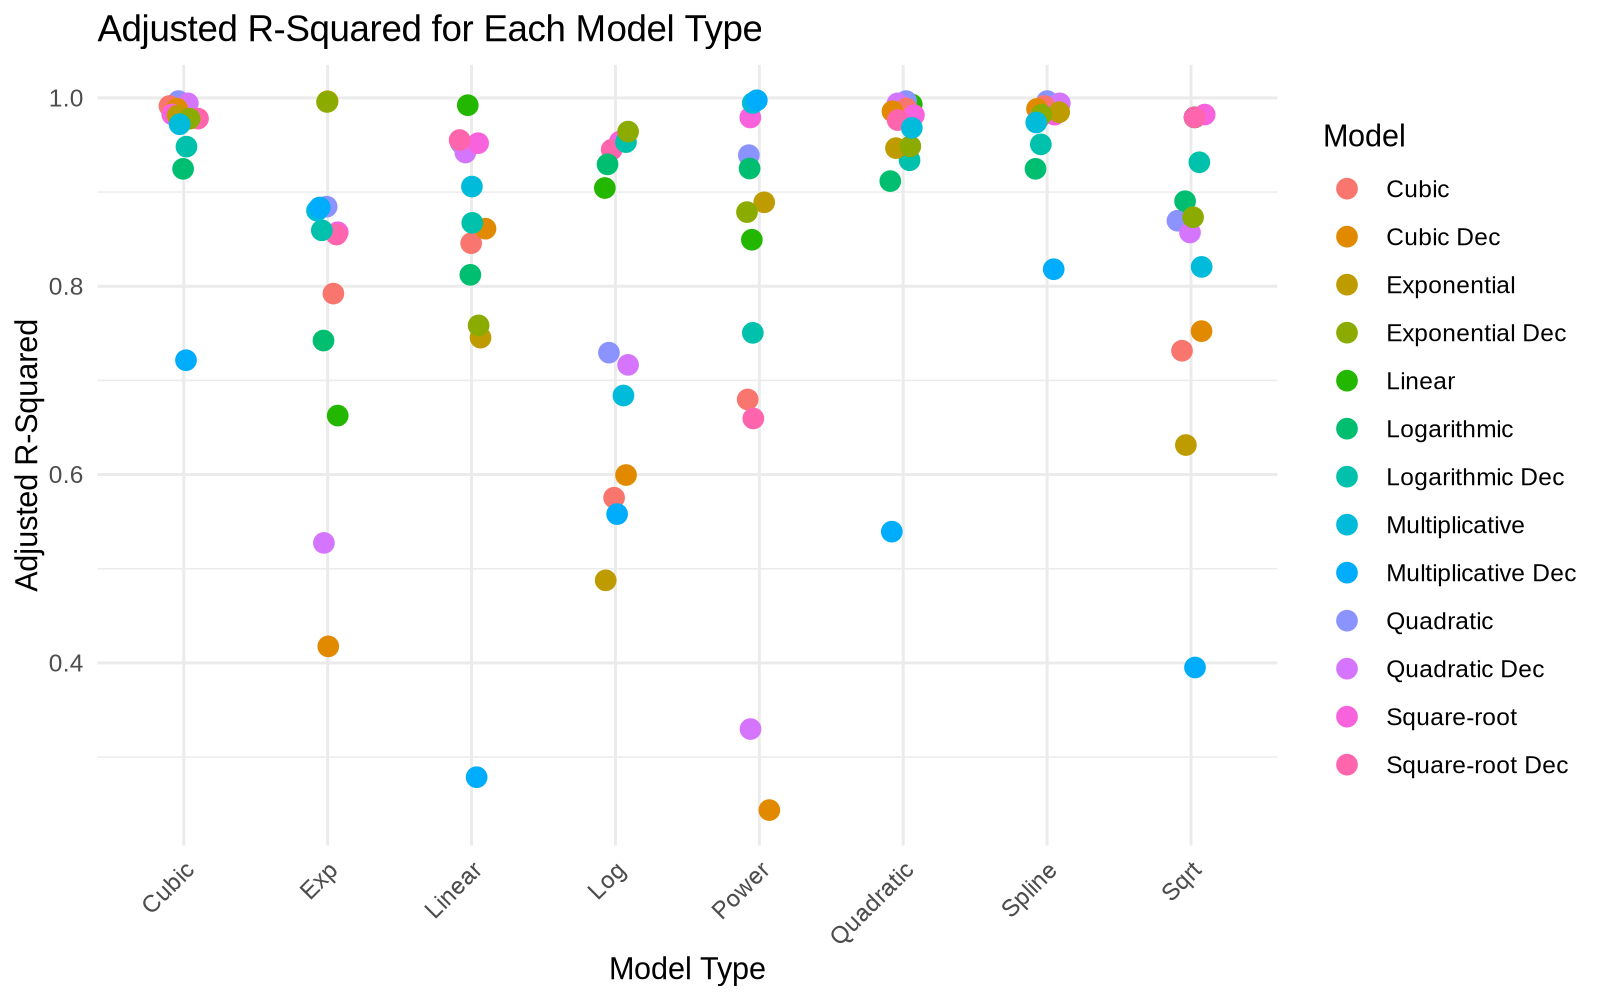

In [31]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

experiment_df_long <- experiment_df %>%
    pivot_longer(-Model, names_to = "Model_Type", values_to = "Adj_R_Squared")

ggplot(experiment_df_long, aes(x = Model_Type, y = Adj_R_Squared, color = Model)) +
    geom_jitter(size = 3, width = 0.1) +
    labs(
        title = "Adjusted R-Squared for Each Model Type",
        x = "Model Type",
        y = "Adjusted R-Squared"
    ) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))


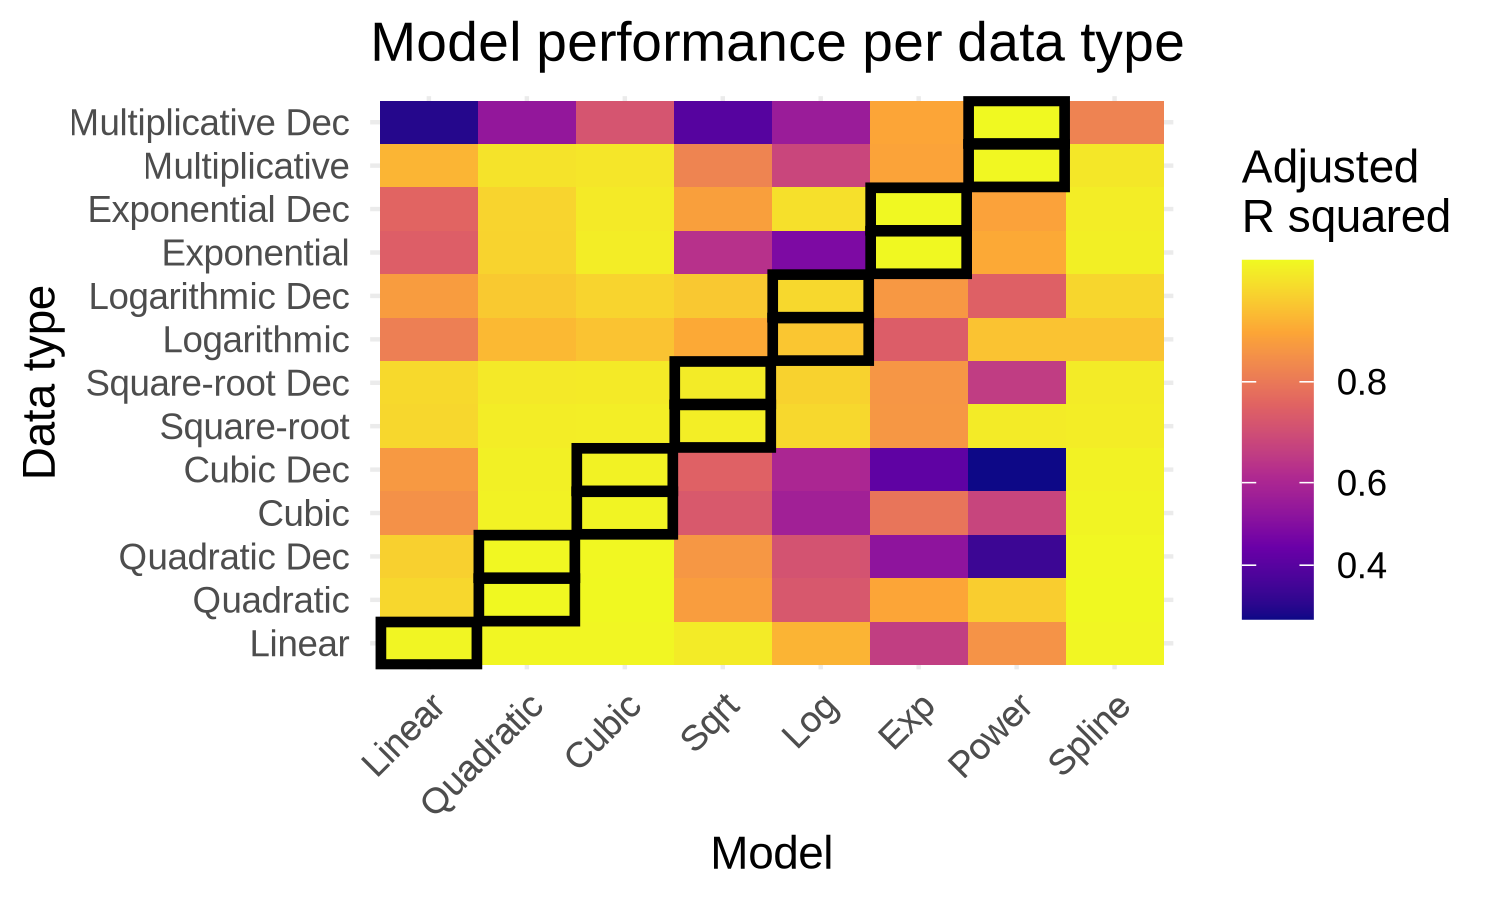

In [33]:
# Prepare data for heatmap
experiment_df_heat <- experiment_df
rownames(experiment_df_heat) <- experiment_df_heat$Model
experiment_df_heat$Model <- NULL

# Convert to matrix for heatmap
mat <- as.matrix(experiment_df_heat)

# Plot heatmap using ggplot2
experiment_df_long2 <- reshape2::melt(mat)
colnames(experiment_df_long2) <- c("Model", "Model_Type", "Adj_R_Squared")

options(repr.plot.width = 5, repr.plot.height = 3, repr.plot.res = 300)


# Define which model should predict which data type
highlight_boxes <- data.frame(
    Model_Type = c("Linear", "Quadratic", "Quadratic", "Cubic", "Cubic", "Sqrt", "Sqrt", "Log", "Log", "Exp", "Exp", "Power", "Power"),
    Model = c("Linear", "Quadratic", "Quadratic Dec", "Cubic", "Cubic Dec", "Square-root", "Square-root Dec", "Logarithmic", "Logarithmic Dec", "Exponential", "Exponential Dec", "Multiplicative", "Multiplicative Dec")
)

ggplot(experiment_df_long2, aes(x = Model_Type, y = Model, fill = Adj_R_Squared)) +
    geom_tile() +
    scale_fill_viridis_c(option = "plasma", trans = scales::exp_trans()) +
    ggnewscale::new_scale_color() +
    geom_tile(
        data = highlight_boxes,
        aes(x = Model_Type, y = Model),
        fill = NA, color = "black", linewidth = 1.2, width = 0.98, height = 0.98, inherit.aes = FALSE
    ) +
    labs(title = "Model performance per data type", x = "Model", y = "Data type", fill = "Adjusted\nR squared") +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
